In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [8]:
df=pd.read_csv("zepto_orders_raw.csv")
df.head()

,order_id,order_placed_at,store_id,store_lat,store_lon,delivery_zone,city,city_tier,customer_lat,customer_lon,...,previous_acceptance_rate,rider_earnings_today,current_incentive,delivery_charge,delivery_time_minutes,rider_accepted,historical_delivery_cost,historical_travel_time,promo_code_applied,data_source
0,ZPO0030634,2026-03-22 22:33:00,DS0027,12.846820,77.573191,BEN-Z13,Bengaluru,1,12.860161,77.575804,...,0.783,291.63,28.0,51.40,20.76,1,50.940,24.935,NaN,zepto_ops_export_v2
1,ZPO0008581,16/02/2026 14:16,DS0044,19.045278,72.894492,MUM-Z05,Mumbai,1,19.039069,72.904669,...,0.582,478.75,40.0,45.76,26.00,1,63.748,30.733,NaN,zepto_ops_export_v2
2,ZPO0056490,2026-02-19 13:46:00,DS0035,17.432337,78.531114,HYD-Z07,Hyderabad,1,17.441617,78.514133,...,0.835,951.57,45.61,51.81,21.82,1,56.481,26.108,NaN,zepto_ops_export_v2
3,ZPO0043495,2026-02-25 20:51:00,DS0024,13.065923,77.533601,BEN-Z10,Bengaluru,1,13.079372,77.549791,...,0.928,1537.62,52.71,65.78,30.36,1,68.848,35.267,NaN,zepto_ops_export_v2
4,ZPO0004606,28/02/2026 23:29,DS0028,12.972781,77.610699,BEN-Z14,Bengaluru,1,12.969402,77.619637,...,0.875,1160.02,20.2,43.29,13.58,1,44.424,22.317,NaN,zepto_ops_export_v2


In [9]:
df.shape

(81280, 39)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
store_lat,81280.0,16.490473,5.641464,9.824670,12.985599,13.102544,19.020807,28.746180
store_lon,81280.0,77.413387,2.287608,72.774727,77.020962,77.573191,78.544213,80.313144
city_tier,81280.0,1.260101,0.627128,1.000000,1.000000,1.000000,1.000000,3.000000
customer_lat,81280.0,16.490557,5.641395,9.729386,12.980732,13.103186,19.029482,28.841977
customer_lon,81280.0,77.413404,2.287637,72.691804,77.049719,77.580275,78.544406,80.405665
distance_km,81280.0,2.837277,2.715368,-3.200000,1.619000,2.338000,3.412000,123.540000
rainfall_mm,77297.0,1.166346,3.181102,0.000000,0.000000,0.000000,0.000000,53.740000
hour,81280.0,15.046457,5.037404,0.000000,11.000000,16.000000,19.000000,23.000000
weekday,81280.0,3.026624,2.005800,0.000000,1.000000,3.000000,5.000000,6.000000
item_count,81280.0,5.146543,3.118807,1.000000,3.000000,5.000000,7.000000,28.000000


In [11]:
df.isnull().sum()

order_id                        0
order_placed_at                 0
store_id                        0
store_lat                       0
store_lon                       0
delivery_zone                   0
city                            0
city_tier                       0
customer_lat                    0
customer_lon                    0
distance_km                     0
road_type                       0
traffic_index                2380
rainfall_mm                  3983
weather_condition               0
hour                            0
weekday                         0
peak_hour_flag                  0
weekend_flag                    0
festival_day_flag               0
item_count                      0
order_amount                    0
order_weight_kg              1660
membership_type               717
demand_level                    0
vehicle_type                    0
rider_experience_months      2419
current_rider_load              0
rider_rating                 3411
previous_accep

In [12]:
df["traffic_index"].value_counts()

traffic_index
0.98      267
0.6473     29
0.6159     29
0.6965     29
0.6498     28
         ... 
0.2401      1
0.9741      1
0.9159      1
0.9669      1
0.9545      1
Name: count, Length: 8157, dtype: int64

In [13]:
df["rainfall_mm"].value_counts()

rainfall_mm
0.00     61383
1.92        33
2.09        32
2.20        31
1.60        31
         ...  
17.40        1
20.06        1
15.42        1
17.07        1
15.32        1
Name: count, Length: 2020, dtype: int64

In [14]:
df['membership_type'].value_counts()

membership_type
none          45006
pass          20385
pass_plus      7317
NONE           1538
 none           767
none            765
-               746
PASS            697
no              682
 pass           367
zepto_pass      361
pass            355
Pass            343
zeptopass       332
PASS_PLUS       262
Pass Plus       147
passplus        136
 pass_plus      128
pass_plus       120
pass+           109
Name: count, dtype: int64

In [15]:
df['rider_rating'].value_counts()

rider_rating
5.0     3484
4.47    1008
4.38     995
4.37     992
4.39     991
        ... 
3.37       1
3.33       1
3.15       1
3.13       1
3.29       1
Name: count, Length: 176, dtype: int64

In [16]:
df['promo_code_applied'].value_counts()

Series([], Name: count, dtype: int64)

In [17]:
df['promo_code_applied']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
81275   NaN
81276   NaN
81277   NaN
81278   NaN
81279   NaN
Name: promo_code_applied, Length: 81280, dtype: float64

In [18]:
df.dtypes

order_id                     object
order_placed_at              object
store_id                     object
store_lat                   float64
store_lon                   float64
delivery_zone                object
city                         object
city_tier                     int64
customer_lat                float64
customer_lon                float64
distance_km                 float64
road_type                    object
traffic_index                object
rainfall_mm                 float64
weather_condition            object
hour                          int64
weekday                       int64
peak_hour_flag               object
weekend_flag                 object
festival_day_flag            object
item_count                    int64
order_amount                 object
order_weight_kg             float64
membership_type              object
demand_level                 object
vehicle_type                 object
rider_experience_months     float64
current_rider_load          

In [19]:
cols = [
    "traffic_index",
    "order_amount",
    "peak_hour_flag",
    "weekend_flag",
    "festival_day_flag",
    "rider_rating",
    "current_incentive",
    "promo_code_applied"
]

for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].unique()[:20])


--- traffic_index ---
['0.5455' '0.414' '0.6352' '0.6359' '0.3505' '0.3213' '0.3475' '0.4916'
 '0.5891' '0.6842' '0.2728' '0.6023' '0.434' '0.468' '0.6931' '0.5741'
 '0.4435' '0.3371' '0.451' '0.3142']

--- order_amount ---
['52.43' '145.17' '49.17' '57.96' '239.13' '₹153.26' '242.08' '50.79'
 '287.08' '115.02' '68.95' '252.15' '122.07' '73.34' '172.84' '56.22'
 '623.55' '111.97' '245.48' '179.45']

--- peak_hour_flag ---
['0' '1' 'TRUE' 'N' 'FALSE' 'Y']

--- weekend_flag ---
['1' '0' 'No' 'Yes']

--- festival_day_flag ---
['0' 'FALSE' '1' 'N' 'Y' 'TRUE']

--- rider_rating ---
['4.71' '4.03' '4.81' '4.8' '4.47' '4.39' nan '4.19' '4.35' '4.62' '4.78'
 '4.95' '4.7' '4.24' '4.57' '3.98' '4.56' '4.26' '4.16' '4.2']

--- current_incentive ---
['28.0' '40.0' '45.61' '52.71' '20.2' '51.72' '19.01' '38.46' '36.61'
 '35.73' '34.46' '48.04' '22.14' '35.33' '62.38' '41.81' '23.37' '39.18'
 '38.92' '47.43']

--- promo_code_applied ---
[nan]


In [20]:
flag_columns = [
    "peak_hour_flag",
    "weekend_flag",
    "festival_day_flag"
]

flag_mapping = {
    "0": 0,
    "1": 1,
    "TRUE": 1,
    "FALSE": 0,
    "Y": 1,
    "N": 0,
    "Yes": 1,
    "No": 0
}

for col in flag_columns:
    df[col] = df[col].replace(flag_mapping)
    #df[col] = df[col].astype(int)

C:\Users\shree\AppData\Local\Temp\ipykernel_2724\231445903.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(flag_mapping)


In [21]:
df[flag_columns].head()

,peak_hour_flag,weekend_flag,festival_day_flag
0,0,1,0
1,0,0,0
2,1,0,0
3,1,0,0
4,0,1,0


In [22]:
df[flag_columns].dtypes

peak_hour_flag       int64
weekend_flag         int64
festival_day_flag    int64
dtype: object

In [23]:
df["traffic_index"] = pd.to_numeric(
    df["traffic_index"],
    errors="coerce"
)

In [24]:
df["order_amount"] = (
    df["order_amount"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.strip()
)

df["order_amount"] = pd.to_numeric(
    df["order_amount"],
    errors="coerce"
)

In [25]:
df["rider_rating"] = pd.to_numeric(
    df["rider_rating"],
    errors="coerce"
)

In [26]:
numeric_columns = [
    "traffic_index",
    "order_amount",
    "rider_rating",
    "current_incentive"
]

df[numeric_columns].dtypes

traffic_index        float64
order_amount         float64
rider_rating         float64
current_incentive     object
dtype: object

In [27]:
df["current_incentive"].unique()

array(['28.0', '40.0', '45.61', ..., 'INR 43.77', '129.79', 'INR 42.02'],
      shape=(11313,), dtype=object)

In [28]:
df['current_incentive']=(df['current_incentive'].astype(str).str.replace('₹','',regex=False).str.strip())

In [29]:
df['current_incentive']=pd.to_numeric(df['current_incentive'],errors='coerce')

In [30]:
df["current_incentive"].isna().sum()

np.int64(2358)

In [31]:
df["current_incentive"].value_counts()

current_incentive
42.13     34
41.09     34
38.17     34
39.36     33
39.08     33
          ..
129.61     1
122.96     1
86.72      1
110.45     1
88.07      1
Name: count, Length: 9384, dtype: int64

In [32]:
df['current_incentive']=df['current_incentive'].fillna(0)

In [33]:
df["current_incentive"].dtype

dtype('float64')

In [34]:
df["current_incentive"].describe()

count    81280.000000
mean        47.655236
std         21.089164
min          0.000000
25%         34.790000
50%         45.470000
75%         58.360000
max        217.760000
Name: current_incentive, dtype: float64

In [35]:
numeric_columns

['traffic_index', 'order_amount', 'rider_rating', 'current_incentive']

In [36]:
flag_columns

['peak_hour_flag', 'weekend_flag', 'festival_day_flag']

In [37]:
df[['traffic_index', 'order_amount', 'rider_rating', 'current_incentive','peak_hour_flag', 'weekend_flag', 'festival_day_flag']].isna().sum()

traffic_index        5531
order_amount            3
rider_rating         3790
current_incentive       0
peak_hour_flag          0
weekend_flag            0
festival_day_flag       0
dtype: int64

In [38]:
df[['traffic_index', 'order_amount', 'rider_rating']].describe()

,traffic_index,order_amount,rider_rating
count,75749.000000,81277.000000,77490.000000
mean,0.558225,166.976118,4.444665
std,0.177622,148.428242,0.308152
min,0.181400,35.000000,3.130000
25%,0.398700,64.460000,4.240000
50%,0.578000,123.220000,4.450000
75%,0.699400,219.660000,4.670000
max,0.980000,3019.290000,5.000000


In [39]:
avg=['traffic_index', 'order_amount', 'rider_rating']
avg

['traffic_index', 'order_amount', 'rider_rating']

In [40]:
for col in avg:
  df[col]=df[col].fillna(df[col].median())

In [41]:
df[avg].isna().sum()

traffic_index    0
order_amount     0
rider_rating     0
dtype: int64

In [42]:
df.isnull().sum()

order_id                        0
order_placed_at                 0
store_id                        0
store_lat                       0
store_lon                       0
delivery_zone                   0
city                            0
city_tier                       0
customer_lat                    0
customer_lon                    0
distance_km                     0
road_type                       0
traffic_index                   0
rainfall_mm                  3983
weather_condition               0
hour                            0
weekday                         0
peak_hour_flag                  0
weekend_flag                    0
festival_day_flag               0
item_count                      0
order_amount                    0
order_weight_kg              1660
membership_type               717
demand_level                    0
vehicle_type                    0
rider_experience_months      2419
current_rider_load              0
rider_rating                    0
previous_accep

In [43]:
ballance_null=["rainfall_mm","order_weight_kg","membership_type","rider_experience_months"]

In [44]:
for col in ballance_null:
  print("--"*20)
  print(col)
  print(df[col].describe())
  print("--"*20)
  print(df[col].isna().sum())

----------------------------------------
rainfall_mm
count    77297.000000
mean         1.166346
std          3.181102
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         53.740000
Name: rainfall_mm, dtype: float64
----------------------------------------
3983
----------------------------------------
order_weight_kg
count    79620.000000
mean        75.852662
std        603.285577
min          0.150000
25%          0.879000
50%          1.796000
75%          3.478000
max      30000.000000
Name: order_weight_kg, dtype: float64
----------------------------------------
1660
----------------------------------------
membership_type
count     80563
unique       20
top        none
freq      45006
Name: membership_type, dtype: object
----------------------------------------
717
----------------------------------------
rider_experience_months
count    78861.000000
mean        -4.250074
std        140.692768
min       -999.000000
25%          7.800

In [45]:
float_values=["rainfall_mm","order_weight_kg","rider_experience_months"]
for col in float_values:
  df[col]=df[col].fillna(df[col].median())

In [46]:
df["membership_type"].value_counts().sort_values(ascending=False)

membership_type
none          45006
pass          20385
pass_plus      7317
NONE           1538
 none           767
none            765
-               746
PASS            697
no              682
 pass           367
zepto_pass      361
pass            355
Pass            343
zeptopass       332
PASS_PLUS       262
Pass Plus       147
passplus        136
 pass_plus      128
pass_plus       120
pass+           109
Name: count, dtype: int64

In [47]:
df["membership_type"].unique()

array(['none', 'pass', 'pass_plus', ' none', '-', 'PASS', 'no', ' pass',
       'pass_plus ', 'Pass', ' pass_plus', 'passplus', 'NONE', nan,
       'PASS_PLUS', 'none ', 'pass ', 'Pass Plus', 'pass+', 'zepto_pass',
       'zeptopass'], dtype=object)

In [48]:
df["membership_type"]=(
    df["membership_type"]
   .fillna("none")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
    .str.replace("-", "none", regex=False)
    .str.replace("_", "", regex=False)
    .str.replace("+", "plus", regex=False)
)

In [49]:
df["membership_type"] = df["membership_type"].replace({
    "pass": "Pass",
    'pass_plus': "Pass Plus",
    "zeptopass": "Pass",
    "no": "None",
    "none": "None",
})

In [50]:
df["membership_type"].unique()

array(['None', 'Pass', 'passplus'], dtype=object)

In [51]:
df["membership_type"].value_counts()

membership_type
None        50221
Pass        22840
passplus     8219
Name: count, dtype: int64

In [52]:
sorted(df["city"].unique())

['BANGALORE',
 'BANGALORE ',
 'Bangalore',
 'Bangalore ',
 'Bengaluru',
 'Benglore',
 'Benglore ',
 'Bombay',
 'Bombay ',
 'Chennai',
 'Coimbatore',
 'Delhi',
 'Delhi ',
 'Delhi NCR',
 'HYD',
 'HYD ',
 'Hyderabad',
 'Kovai',
 'Kovai ',
 'MAA',
 'MAA ',
 'Madras',
 'Madras ',
 'Madurai',
 'Mumbai',
 'Mysore',
 'Mysore ',
 'Mysuru',
 'NCR',
 'NCR ',
 'New Delhi',
 'New Delhi ',
 'Secunderabad',
 'Secunderabad ',
 'Tiruchirappalli',
 'Tiruchirappalli ',
 'Trichy',
 'bengaluru',
 'bengaluru ',
 'blr',
 'blr ',
 'cbe',
 'cbe ',
 'chennai',
 'chennai ',
 'delhi-ncr',
 'delhi-ncr ',
 'hyd',
 'hyd ',
 'kovai',
 'kovai ',
 'madurai',
 'madurai ',
 'mumbai',
 'mumbai ',
 'mysore',
 'mysore ',
 'trichy',
 'trichy ']

In [53]:
df["city"]=(
    df["city"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "", regex=False)
    )

In [54]:
df["city"] = df["city"].replace({
    "bangalore": "bengaluru",
    'benglore': "bengaluru",
    "cbe": "coimbatore",
    "delhi-ncr": "delhi",
    "delhincr": "delhi",
    "hyd": "hyderabad",
    "kovai": "coimbatore",
    "madras": "chennai",
    "mysuru": "mysore",
     "blr": "bengaluru",
    "bombay": "mumbai",
    "maa": "chennai",
    "ncr": "delhi",
    "newdelhi": "delhi",
    "tiruchirappalli": "trichy"
})

In [55]:
sorted(df["city"].unique())

['bengaluru',
 'chennai',
 'coimbatore',
 'delhi',
 'hyderabad',
 'madurai',
 'mumbai',
 'mysore',
 'secunderabad',
 'trichy']

In [56]:
df["road_type"].value_counts(dropna=False)

road_type
arterial        30658
residential     26036
narrow_lane     12093
highway          7686
artrial           666
ARTERIAL          647
Arterial          611
resedential       546
Residential       543
residental        538
narrow lane       279
Narrow_Lane       266
narrowlane        259
high way          170
HIGHWAY           142
highwy            140
Name: count, dtype: int64

In [57]:
df["road_type"] = df["road_type"].str.strip().str.lower()

df["road_type"] = df["road_type"].replace({
    "artrial": "arterial",
    "resedential": "residential",
    "residental": "residential",
    "narrow lane": "narrow_lane",
    "narrowlane": "narrow_lane",
    "high way": "highway",
    "highwy": "highway"
})

In [58]:
df["road_type"].value_counts()

road_type
arterial       32582
residential    27663
narrow_lane    12897
highway         8138
Name: count, dtype: int64

In [59]:
df["weather_condition"].value_counts(dropna=False)

weather_condition
clear            59613
light_rain        9563
moderate_rain     6539
clr                947
Clear              936
CLEAR              915
sunny              882
heavy_rain         852
Light_Rain         160
moderate rain      145
lightrain          142
light rain         141
drizzle            140
mod_rain           135
Moderate_Rain      121
Heavy_Rain          14
heavy rain          14
downpour            11
heavyrain           10
Name: count, dtype: int64

In [60]:
df["weather_condition"] = (
    df["weather_condition"]
    .str.strip()
    .str.lower()
)

df["weather_condition"] = df["weather_condition"].replace({
    "clr": "clear",
    "sunny": "clear",

    "light rain": "light_rain",
    "lightrain": "light_rain",
    "drizzle": "light_rain",

    "moderate rain": "moderate_rain",
    "mod_rain": "moderate_rain",

    "heavy rain": "heavy_rain",
    "heavyrain": "heavy_rain",
    "downpour": "heavy_rain"
})

In [61]:
df["weather_condition"].value_counts()

weather_condition
clear            63293
light_rain       10146
moderate_rain     6940
heavy_rain         901
Name: count, dtype: int64

In [62]:
df["demand_level"].value_counts(dropna=False)

demand_level
low       32145
medium    26631
high      17565
l           711
Low         695
LOW         686
MEDIUM      445
mediun      434
Medium      432
med         382
h           298
HIGH        297
High        280
hgh         279
Name: count, dtype: int64

In [63]:
df["demand_level"] = (
    df["demand_level"]
    .str.strip()
    .str.lower()
)

df["demand_level"] = df["demand_level"].replace({
    "l": "low",

    "mediun": "medium",
    "med": "medium",

    "h": "high",
    "hgh": "high"
})

In [64]:
df["demand_level"].value_counts()

demand_level
low       34237
medium    28324
high      18719
Name: count, dtype: int64

In [65]:
df["vehicle_type"].value_counts(dropna=False)

vehicle_type
bike        37622
scooter     20374
ev_bike     10169
bicycle      4400
SCOOTER       722
bike          695
 bike         684
BIKE          665
BIKE          641
Bke           632
bikee         622
bik           605
scooter       367
Scooter       364
 scooter      341
scoter        331
scootr        331
 ev_bike      187
ev bike       181
ev_bik        172
EV-Bike       169
ev_bike       162
EV_BIKE       158
evbike        154
cycle          82
bycycle        82
bicyle         81
 bicycle       78
BICYCLE        77
Bicycle        72
bicycle        60
Name: count, dtype: int64

In [66]:
df["vehicle_type"] = (
    df["vehicle_type"]
    .str.strip()
    .str.lower()
)

df["vehicle_type"] = df["vehicle_type"].replace({
    "bke": "bike",
    "bikee": "bike",
    "bik": "bike",

    "scoter": "scooter",
    "scootr": "scooter",

    "ev bike": "ev_bike",
    "ev_bik": "ev_bike",
    "ev-bike": "ev_bike",
    "evbike": "ev_bike",

    "cycle": "bicycle",
    "bycycle": "bicycle",
    "bicyle": "bicycle"
})

In [67]:
df["vehicle_type"].value_counts()

vehicle_type
bike       42166
scooter    22830
ev_bike    11352
bicycle     4932
Name: count, dtype: int64

In [68]:
df["data_source"].value_counts(dropna=False)

data_source
zepto_ops_export_v2    81280
Name: count, dtype: int64

In [69]:
df["delivery_zone"].value_counts(dropna=False)

delivery_zone
BEN-Z14    1209
CHE-Z08    1206
BEN-Z01    1198
CHE-Z07    1191
CHE-Z04    1188
           ... 
TRI-Z04     483
MYS-Z04     480
TRI-Z05     477
MYS-Z01     463
MYS-Z02     454
Name: count, Length: 87, dtype: int64

In [70]:
df["delivery_zone"].str.match(r"^[A-Z]{3}-Z\d{2}$").value_counts()

delivery_zone
True    81280
Name: count, dtype: int64

In [71]:
df["store_id"].value_counts(dropna=False).head(20)

store_id
DS0028    1209
DS0008    1206
DS0015    1198
DS0007    1191
DS0004    1188
DS0024    1186
DS0011    1186
DS0027    1183
DS0019    1174
DS0002    1165
DS0016    1159
DS0009    1157
DS0014    1157
DS0023    1156
DS0022    1154
DS0010    1150
DS0001    1142
DS0044    1142
DS0005    1133
DS0017    1127
Name: count, dtype: int64

In [72]:
df["order_id"].value_counts().head(20)

order_id
ZPO0028046    3
ZPO0065338    3
ZPO0031015    3
ZPO0021560    3
ZPO0018903    3
ZPO0048419    2
ZPO0022393    2
ZPO0061407    2
ZPO0027768    2
ZPO0010580    2
ZPO0066492    2
ZPO0043289    2
ZPO0015043    2
ZPO0027577    2
ZPO0051459    2
ZPO0041958    2
ZPO0028927    2
ZPO0065105    2
ZPO0069699    2
ZPO0008172    2
Name: count, dtype: int64

In [73]:
df[df["order_id"].duplicated(keep=False)].groupby("order_id").size().value_counts()

2    1270
3       5
Name: count, dtype: int64

In [74]:
df[df["order_id"].duplicated(keep=False)].sort_values("order_id").head(20)

,order_id,order_placed_at,store_id,store_lat,store_lon,delivery_zone,city,city_tier,customer_lat,customer_lon,...,previous_acceptance_rate,rider_earnings_today,current_incentive,delivery_charge,delivery_time_minutes,rider_accepted,historical_delivery_cost,historical_travel_time,promo_code_applied,data_source
37084,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,NaN,zepto_ops_export_v2
55988,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,NaN,zepto_ops_export_v2
76208,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,NaN,zepto_ops_export_v2
13199,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,NaN,zepto_ops_export_v2
63817,ZPO0000343,2026-05-01 18:26:00,DS0058,28.640905,77.121366,DEL-Z07,delhi,1,28.669006,77.135707,...,0.773,1744.57,56.96,31.52,29.83,0,69.168,32.106,NaN,zepto_ops_export_v2
59280,ZPO0000343,2026-05-01 18:26:00,DS0058,28.640905,77.121366,DEL-Z07,delhi,1,28.669006,77.135707,...,0.773,1744.57,56.96,31.52,29.83,0,69.168,32.106,NaN,zepto_ops_export_v2
45991,ZPO0000430,2026-04-20 17:41:00,DS0059,28.667966,77.154585,DEL-Z08,delhi,1,28.647454,77.161879,...,0.646,808.66,31.70,42.95,24.07,1,68.110,31.478,NaN,zepto_ops_export_v2
6663,ZPO0000430,2026-04-20 17:41:00,DS0059,28.667966,77.154585,DEL-Z08,delhi,1,28.647454,77.161879,...,0.646,808.66,31.70,42.95,24.07,1,68.110,31.478,NaN,zepto_ops_export_v2
5726,ZPO0000436,02/03/2026 12:12,DS0015,13.009524,77.554209,BEN-Z01,bengaluru,1,13.014446,77.538845,...,0.961,2398.83,40.28,40.75,22.08,1,53.389,25.083,NaN,zepto_ops_export_v2
18719,ZPO0000436,02/03/2026 12:12,DS0015,13.009524,77.554209,BEN-Z01,bengaluru,1,13.014446,77.538845,...,0.961,2398.83,40.28,40.75,22.08,1,53.389,25.083,NaN,zepto_ops_export_v2


In [75]:
duplicate_data = df[df["order_id"].duplicated(keep=False)]

duplicate_data.groupby("order_id").nunique().max().sort_values(ascending=False)

order_placed_at             2
rider_rating                2
order_amount                2
order_weight_kg             2
item_count                  2
traffic_index               2
rider_experience_months     2
current_incentive           2
city                        1
store_lat                   1
store_id                    1
delivery_zone               1
store_lon                   1
distance_km                 1
weather_condition           1
rainfall_mm                 1
road_type                   1
hour                        1
weekend_flag                1
city_tier                   1
customer_lon                1
customer_lat                1
festival_day_flag           1
weekday                     1
peak_hour_flag              1
demand_level                1
vehicle_type                1
current_rider_load          1
previous_acceptance_rate    1
membership_type             1
rider_earnings_today        1
delivery_charge             1
delivery_time_minutes       1
rider_acce

In [76]:
duplicate_data.shape

(2555, 39)

In [77]:
df["order_id"].nunique(), len(df)

(80000, 81280)

In [78]:
df["traffic_index"].describe()

count    81280.000000
mean         0.559571
std          0.171544
min          0.181400
25%          0.408200
50%          0.578000
75%          0.691200
max          0.980000
Name: traffic_index, dtype: float64

In [79]:
df["rainfall_mm"].describe()

count    81280.000000
mean         1.109191
std          3.112381
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         53.740000
Name: rainfall_mm, dtype: float64

In [80]:
df["order_amount"].describe()

count    81280.000000
mean       166.974503
std        148.425740
min         35.000000
25%         64.460000
50%        123.220000
75%        219.652500
max       3019.290000
Name: order_amount, dtype: float64

In [81]:
df.nlargest(20, "order_amount")[
    ["order_amount", "item_count", "order_weight_kg", "distance_km", "city"]
]

,order_amount,item_count,order_weight_kg,distance_km,city
912,3019.29,16,9.577,2.396,delhi
66784,2095.10,15,17.257,1.391,bengaluru
78911,1970.88,18,1.796,2.595,madurai
1791,1905.51,14,7.690,3.396,trichy
77184,1890.04,23,9.800,1.296,mumbai
21377,1734.67,19,2.816,70.780,mumbai
32118,1702.40,20,3.904,2.668,chennai
833,1701.68,16,2.948,1.294,bengaluru
38789,1682.98,16,5.956,1.982,bengaluru
45834,1660.89,21,5.379,1.950,chennai


In [82]:
df["order_weight_kg"].describe()

count    81280.000000
mean        74.340186
std        597.185075
min          0.150000
25%          0.894000
50%          1.796000
75%          3.424000
max      30000.000000
Name: order_weight_kg, dtype: float64

In [83]:
(df["order_weight_kg"] > 30).sum()

np.int64(2387)

In [84]:
df[df["order_weight_kg"] > 30][
    ["order_weight_kg", "item_count", "order_amount", "distance_km", "city"]
].head(20)

,order_weight_kg,item_count,order_amount,distance_km,city
13,401.0,6,73.34,1.946,delhi
78,798.0,2,35.00,3.007,bengaluru
89,956.0,4,142.05,4.850,bengaluru
92,411.0,3,35.00,1.564,bengaluru
141,3230.0,6,124.61,2.193,mumbai
156,1320.0,4,35.00,2.261,hyderabad
165,3548.0,4,151.26,1.961,bengaluru
203,406.0,1,35.00,3.714,mumbai
247,1309.0,3,64.32,1.695,hyderabad
321,1352.0,4,373.71,1.317,chennai


In [85]:
df[df["order_weight_kg"] > 30][
    ["order_weight_kg", "item_count"]
].assign(
    weight_per_item=lambda x: x["order_weight_kg"] / x["item_count"]
).head(20)

,order_weight_kg,item_count,weight_per_item
13,401.0,6,66.833333
78,798.0,2,399.000000
89,956.0,4,239.000000
92,411.0,3,137.000000
141,3230.0,6,538.333333
156,1320.0,4,330.000000
165,3548.0,4,887.000000
203,406.0,1,406.000000
247,1309.0,3,436.333333
321,1352.0,4,338.000000


In [86]:
df[df["order_weight_kg"].between(10, 30)][
    ["order_weight_kg", "item_count", "order_amount", "distance_km", "city"]
].head(20)

,order_weight_kg,item_count,order_amount,distance_km,city
63,12.631,14,483.33,2.222,bengaluru
69,11.951,7,284.41,1.223,chennai
169,10.328,16,477.87,1.092,hyderabad
206,11.297,13,835.50,3.542,coimbatore
215,17.146,11,417.28,1.448,chennai
249,24.548,14,139.55,3.062,delhi
323,10.408,14,378.94,6.517,hyderabad
342,10.498,9,35.00,1.856,chennai
355,19.128,19,613.12,2.274,bengaluru
450,10.711,6,362.83,1.835,hyderabad


In [87]:
df[df["order_weight_kg"] > 30]["order_weight_kg"].describe()

count     2387.000000
mean      2449.831588
std       2516.398590
min        150.000000
25%        840.500000
50%       1709.000000
75%       3236.500000
max      30000.000000
Name: order_weight_kg, dtype: float64

In [88]:
mask = df["order_weight_kg"] > 30

df.loc[mask, "order_weight_kg"] = (
    df.loc[mask, "order_weight_kg"] / 1000
)

In [89]:
df["order_weight_kg"].describe()

count    81280.000000
mean         2.466413
std          2.435741
min          0.150000
25%          0.870000
50%          1.772000
75%          3.208000
max         30.000000
Name: order_weight_kg, dtype: float64

In [90]:
(df["order_weight_kg"] > 30).sum()

np.int64(0)

In [91]:
df["delivery_time_minutes"].describe()

count    81280.000000
mean        27.069090
std         11.640932
min          6.070000
25%         19.520000
50%         24.410000
75%         31.550000
max        205.530000
Name: delivery_time_minutes, dtype: float64

In [92]:
df.nlargest(20, "delivery_time_minutes")[
    [
        "delivery_time_minutes",
        "distance_km",
        "traffic_index",
        "rainfall_mm",
        "weather_condition",
        "city",
        "road_type"
    ]
]

,delivery_time_minutes,distance_km,traffic_index,rainfall_mm,weather_condition,city,road_type
50873,205.53,12.406,0.7669,0.00,clear,chennai,narrow_lane
8281,202.28,13.984,0.7855,3.30,light_rain,mumbai,residential
50812,186.98,13.984,0.8014,0.00,clear,bengaluru,arterial
65656,163.79,9.962,0.8197,10.12,moderate_rain,delhi,residential
16275,157.32,9.237,0.9800,16.10,heavy_rain,bengaluru,narrow_lane
66654,149.13,10.175,0.8913,14.11,moderate_rain,bengaluru,narrow_lane
885,149.04,13.981,0.6907,0.00,clear,delhi,narrow_lane
20973,147.08,12.787,0.6637,0.00,clear,delhi,residential
76664,145.56,8.999,0.9800,14.61,moderate_rain,mumbai,residential
41502,143.52,10.517,0.4360,4.30,light_rain,mumbai,narrow_lane


In [93]:
(df["delivery_time_minutes"] > 60).sum()

np.int64(1628)

In [94]:
df[df["delivery_time_minutes"] > 60][
    ["delivery_time_minutes", "distance_km", "traffic_index", "rainfall_mm", "city"]
].describe()

,delivery_time_minutes,distance_km,traffic_index,rainfall_mm
count,1628.000000,1628.000000,1628.000000,1628.000000
mean,74.001007,7.830185,0.677390,2.500154
std,15.653745,6.884676,0.153811,5.083482
min,60.010000,0.000000,0.229400,0.000000
25%,63.547500,5.466000,0.578000,0.000000
50%,68.895000,6.934500,0.691500,0.000000
75%,78.232500,8.859250,0.786075,2.630000
max,205.530000,123.540000,0.980000,35.410000


In [95]:
df[
    (df["delivery_time_minutes"] > 60) &
    (df["distance_km"] <= 5)
][
    [
        "delivery_time_minutes",
        "distance_km",
        "traffic_index",
        "rainfall_mm",
        "weather_condition",
        "city",
        "road_type"
    ]
].sort_values(
    "delivery_time_minutes",
    ascending=False
).head(20)

,delivery_time_minutes,distance_km,traffic_index,rainfall_mm,weather_condition,city,road_type
80401,94.30,4.739,0.6944,0.00,clear,bengaluru,narrow_lane
59300,87.59,4.646,0.6522,0.00,clear,delhi,narrow_lane
57383,86.96,4.831,0.7217,1.39,light_rain,bengaluru,narrow_lane
3773,85.25,4.985,0.6536,0.00,clear,hyderabad,narrow_lane
35276,84.18,4.774,0.6535,0.00,light_rain,delhi,narrow_lane
39214,84.01,4.127,0.5780,8.66,moderate_rain,mumbai,arterial
79520,83.69,4.852,0.8280,0.00,clear,delhi,residential
59239,82.69,4.551,0.9800,19.11,heavy_rain,chennai,arterial
20766,81.92,4.490,0.5111,11.46,moderate_rain,bengaluru,narrow_lane
313,80.33,3.922,0.9800,0.00,moderate_rain,mumbai,residential


In [96]:
df[
    (df["delivery_time_minutes"] > 60) &
    (df["distance_km"] <= 5)
][
    [
        "delivery_time_minutes",
        "historical_travel_time",
        "distance_km",
        "traffic_index",
        "rainfall_mm",
        "city"
    ]
].sort_values(
    "delivery_time_minutes",
    ascending=False
).head(20)

,delivery_time_minutes,historical_travel_time,distance_km,traffic_index,rainfall_mm,city
80401,94.30,26.319,4.739,0.6944,0.00,bengaluru
59300,87.59,33.365,4.646,0.6522,0.00,delhi
57383,86.96,12.720,4.831,0.7217,1.39,bengaluru
3773,85.25,37.256,4.985,0.6536,0.00,hyderabad
35276,84.18,27.514,4.774,0.6535,0.00,delhi
39214,84.01,24.731,4.127,0.5780,8.66,mumbai
79520,83.69,29.499,4.852,0.8280,0.00,delhi
59239,82.69,33.523,4.551,0.9800,19.11,chennai
20766,81.92,17.003,4.490,0.5111,11.46,bengaluru
313,80.33,21.380,3.922,0.9800,0.00,mumbai


In [97]:
df["travel_time_diff"] = (
    df["delivery_time_minutes"]
    - df["historical_travel_time"]
)

df["travel_time_diff"].describe()

count    81280.000000
mean        -2.205620
std         16.774747
min       -249.091000
25%        -10.531000
50%         -2.786500
75%          6.384000
max        184.338000
Name: travel_time_diff, dtype: float64

In [98]:
df.nlargest(20, "travel_time_diff")[
    [
        "delivery_time_minutes",
        "historical_travel_time",
        "travel_time_diff",
        "distance_km",
        "traffic_index",
        "rainfall_mm",
        "city"
    ]
]

,delivery_time_minutes,historical_travel_time,travel_time_diff,distance_km,traffic_index,rainfall_mm,city
50873,205.53,21.192,184.338,12.406,0.7669,0.00,chennai
8281,202.28,28.391,173.889,13.984,0.7855,3.30,mumbai
50812,186.98,24.202,162.778,13.984,0.8014,0.00,bengaluru
16275,157.32,22.275,135.045,9.237,0.9800,16.10,bengaluru
65656,163.79,29.660,134.130,9.962,0.8197,10.12,delhi
41502,143.52,22.003,121.517,10.517,0.4360,4.30,mumbai
20973,147.08,26.067,121.013,12.787,0.6637,0.00,delhi
66654,149.13,29.396,119.734,10.175,0.8913,14.11,bengaluru
42535,142.15,24.207,117.943,9.773,0.7100,0.00,chennai
76664,145.56,27.660,117.900,8.999,0.9800,14.61,mumbai


In [99]:
df["travel_time_diff"] = (
    df["delivery_time_minutes"]
    - df["historical_travel_time"]
)

In [100]:
df["travel_time_diff"].describe()

count    81280.000000
mean        -2.205620
std         16.774747
min       -249.091000
25%        -10.531000
50%         -2.786500
75%          6.384000
max        184.338000
Name: travel_time_diff, dtype: float64

In [101]:
df.nsmallest(20, "travel_time_diff")[
    [
        "delivery_time_minutes",
        "historical_travel_time",
        "travel_time_diff",
        "distance_km",
        "traffic_index",
        "city"
    ]
]

,delivery_time_minutes,historical_travel_time,travel_time_diff,distance_km,traffic_index,city
9202,28.88,277.971,-249.091,6.156,0.5780,mysore
55686,18.64,244.718,-226.078,1.623,0.2007,coimbatore
45004,21.37,224.770,-203.400,4.178,0.3492,madurai
23777,18.54,220.884,-202.344,1.408,0.3602,mysore
72537,16.21,200.009,-183.799,1.936,0.3047,madurai
71163,13.14,192.425,-179.285,1.702,0.2938,coimbatore
35309,17.80,196.409,-178.609,1.458,0.2021,coimbatore
723,14.39,169.540,-155.150,2.362,0.5780,madurai
78208,26.95,176.440,-149.490,3.007,0.4295,madurai
32215,18.01,163.183,-145.173,2.062,0.4784,hyderabad


In [102]:
df["historical_travel_time"].describe()

count    81280.000000
mean        29.274710
std         11.105544
min          2.188000
25%         24.150000
50%         27.889000
75%         32.129250
max        277.971000
Name: historical_travel_time, dtype: float64

In [103]:
df["travel_time_diff"] = (
    df["delivery_time_minutes"]
    - df["historical_travel_time"]
)

In [104]:
df["historical_travel_time"].describe()

count    81280.000000
mean        29.274710
std         11.105544
min          2.188000
25%         24.150000
50%         27.889000
75%         32.129250
max        277.971000
Name: historical_travel_time, dtype: float64

In [105]:
(df["historical_travel_time"] > 60).sum()

np.int64(1569)

In [106]:
df[df["historical_travel_time"] > 60][
    [
        "historical_travel_time",
        "distance_km",
        "traffic_index",
        "rainfall_mm",
        "city",
        "road_type"
    ]
].describe()

,historical_travel_time,distance_km,traffic_index,rainfall_mm
count,1569.000000,1569.000000,1569.000000,1569.000000
mean,71.583978,2.816512,0.522975,0.874226
std,20.024396,2.271886,0.162548,2.666961
min,60.004000,-3.200000,0.187900,0.000000
25%,62.103000,1.613000,0.384200,0.000000
50%,65.267000,2.343000,0.554600,0.000000
75%,70.678000,3.332000,0.638400,0.000000
max,277.971000,40.510000,0.980000,26.580000


In [107]:
df[df["historical_travel_time"] > 60][
    ["historical_travel_time", "distance_km"]
].assign(
    corrected_time=lambda x: x["historical_travel_time"] / 10
).head(20)

,historical_travel_time,distance_km,corrected_time
7,60.226,1.743,6.0226
221,63.870,3.493,6.3870
240,60.954,3.717,6.0954
264,61.719,2.938,6.1719
351,135.298,3.025,13.5298
430,66.306,4.721,6.6306
482,68.893,1.814,6.8893
570,64.200,2.315,6.4200
641,60.735,1.219,6.0735
695,62.249,0.815,6.2249


In [108]:
df[df["historical_travel_time"] > 60][
    [
        "historical_travel_time",
        "delivery_time_minutes",
        "distance_km",
        "traffic_index",
        "city"
    ]
].head(20)

,historical_travel_time,delivery_time_minutes,distance_km,traffic_index,city
7,60.226,16.17,1.743,0.4916,mysore
221,63.870,25.85,3.493,0.5452,coimbatore
240,60.954,27.88,3.717,0.5819,trichy
264,61.719,23.30,2.938,0.6333,madurai
351,135.298,25.25,3.025,0.3603,hyderabad
430,66.306,38.35,4.721,0.5599,trichy
482,68.893,18.21,1.814,0.4022,mysore
570,64.200,16.20,2.315,0.5780,trichy
641,60.735,13.38,1.219,0.5757,madurai
695,62.249,20.12,0.815,0.5780,mysore


In [109]:
df[["distance_km", "historical_travel_time"]].corr()

,distance_km,historical_travel_time
distance_km,1.000000,-0.000909
historical_travel_time,-0.000909,1.000000


In [110]:
df[df["historical_travel_time"] <= 60][
    ["distance_km", "historical_travel_time"]
].corr()

,distance_km,historical_travel_time
distance_km,1.000000,0.000104
historical_travel_time,0.000104,1.000000


In [111]:
df["rider_earnings_today"].describe()

count    81280.000000
mean      1209.498385
std        728.485310
min          7.660000
25%        674.187500
50%       1059.925000
75%       1583.502500
max       4200.000000
Name: rider_earnings_today, dtype: float64

In [112]:
(df["rider_earnings_today"] < 0).sum()

np.int64(0)

In [113]:
df["current_incentive"].describe()

count    81280.000000
mean        47.655236
std         21.089164
min          0.000000
25%         34.790000
50%         45.470000
75%         58.360000
max        217.760000
Name: current_incentive, dtype: float64

In [114]:
(df["current_incentive"] < 0).sum()

np.int64(0)

In [115]:
df["delivery_charge"].describe()

count    81280.000000
mean        55.407908
std         19.973909
min         10.000000
25%         42.920000
50%         52.370000
75%         63.770000
max        284.370000
Name: delivery_charge, dtype: float64

In [116]:
(df["delivery_charge"] < 0).sum()

np.int64(0)

In [117]:
df["delivery_time_minutes"].describe()

count    81280.000000
mean        27.069090
std         11.640932
min          6.070000
25%         19.520000
50%         24.410000
75%         31.550000
max        205.530000
Name: delivery_time_minutes, dtype: float64

In [118]:
(df["delivery_time_minutes"] <= 0).sum()

np.int64(0)

In [119]:
df["rider_accepted"].value_counts(dropna=False)

rider_accepted
1    49352
0    31928
Name: count, dtype: int64

In [120]:
df["historical_delivery_cost"].describe()

count    81280.000000
mean        60.227824
std         22.839664
min          4.324000
25%         50.127750
50%         57.620000
75%         65.830000
max        593.332000
Name: historical_delivery_cost, dtype: float64

In [121]:
(df["historical_delivery_cost"] > 200).sum()

np.int64(122)

In [122]:
df[df["historical_delivery_cost"] > 200][
    [
        "historical_delivery_cost",
        "delivery_charge",
        "order_amount",
        "distance_km",
        "city"
    ]
].head(20)

,historical_delivery_cost,delivery_charge,order_amount,distance_km,city
351,286.241,46.22,156.60,3.025,hyderabad
696,202.794,42.97,107.01,2.657,bengaluru
723,362.585,33.39,104.23,2.362,madurai
1111,248.970,62.01,50.76,2.583,hyderabad
1607,212.250,55.54,512.22,4.805,hyderabad
3461,217.866,35.83,181.18,1.579,bengaluru
3622,219.023,51.17,58.48,1.184,mumbai
3678,252.460,60.53,71.03,1.009,mumbai
5618,203.197,24.50,214.71,1.363,trichy
7937,204.485,35.28,199.84,1.157,chennai


In [123]:
df[
    [
        "historical_delivery_cost",
        "delivery_charge",
        "distance_km"
    ]
].corr()

,historical_delivery_cost,delivery_charge,distance_km
historical_delivery_cost,1.000000,-0.126427,-0.000957
delivery_charge,-0.126427,1.000000,0.439654
distance_km,-0.000957,0.439654,1.000000


In [124]:
df["rider_rating"].describe()

count    81280.000000
mean         4.444914
std          0.300884
min          3.130000
25%          4.250000
50%          4.450000
75%          4.650000
max          5.000000
Name: rider_rating, dtype: float64

In [125]:
df["previous_acceptance_rate"].describe()

count    81280.000000
mean         0.714176
std          0.142146
min          0.146000
25%          0.622000
50%          0.730000
75%          0.823000
max          0.990000
Name: previous_acceptance_rate, dtype: float64

In [126]:
df["current_rider_load"].describe()

count    81280.000000
mean         1.504909
std          1.118338
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: current_rider_load, dtype: float64

In [127]:
df["rider_experience_months"].describe()

count    81280.000000
mean        -3.730737
std        138.615048
min       -999.000000
25%          8.000000
50%         13.200000
75%         20.200000
max         90.000000
Name: rider_experience_months, dtype: float64

In [128]:
(df["rider_experience_months"] == -999).sum()

np.int64(1539)

In [129]:
df[df["rider_experience_months"] != -999]["rider_experience_months"].describe()

count    79741.000000
mean        15.477944
std          9.896535
min          0.500000
25%          8.300000
50%         13.200000
75%         20.400000
max         90.000000
Name: rider_experience_months, dtype: float64

In [130]:
df["rider_experience_months"] = df["rider_experience_months"].replace(-999, np.nan)

In [131]:
df["rider_experience_months"].isna().sum()

np.int64(1539)

In [132]:
df["rider_experience_months"] = df["rider_experience_months"].fillna(
    df["rider_experience_months"].median()
)

In [133]:
df["rider_experience_months"].isna().sum()

np.int64(0)

In [134]:
df["historical_travel_time"].describe()

count    81280.000000
mean        29.274710
std         11.105544
min          2.188000
25%         24.150000
50%         27.889000
75%         32.129250
max        277.971000
Name: historical_travel_time, dtype: float64

In [135]:
df["historical_travel_time"].isna().sum()

np.int64(0)

In [136]:
df["current_incentive"].describe()

count    81280.000000
mean        47.655236
std         21.089164
min          0.000000
25%         34.790000
50%         45.470000
75%         58.360000
max        217.760000
Name: current_incentive, dtype: float64

In [137]:
df["delivery_charge"].describe()

count    81280.000000
mean        55.407908
std         19.973909
min         10.000000
25%         42.920000
50%         52.370000
75%         63.770000
max        284.370000
Name: delivery_charge, dtype: float64

In [138]:
df["historical_delivery_cost"].describe()

count    81280.000000
mean        60.227824
std         22.839664
min          4.324000
25%         50.127750
50%         57.620000
75%         65.830000
max        593.332000
Name: historical_delivery_cost, dtype: float64

In [139]:
print("SHAPE:", df.shape)

print("\n--- MISSING VALUES ---")
print(df.isna().sum()[df.isna().sum() > 0])

print("\n--- DUPLICATE ROWS ---")
print("Exact duplicate rows:", df.duplicated().sum())

print("\n--- DUPLICATE ORDER IDs ---")
print("Duplicate order_ids:", df["order_id"].duplicated().sum())

print("\n--- CATEGORICAL VALUES ---")
for col in ["city", "road_type", "demand_level", "vehicle_type", "membership_type"]:
    print(f"\n{col}:")
    print(df[col].value_counts())

print("\n--- NUMERIC VALIDATION ---")
checks = {
    "distance_km < 0": (df["distance_km"] < 0).sum(),
    "order_weight_kg < 0": (df["order_weight_kg"] < 0).sum(),
    "order_weight_kg > 30": (df["order_weight_kg"] > 30).sum(),
    "rider_rating outside 1-5": ((df["rider_rating"] < 1) | (df["rider_rating"] > 5)).sum(),
    "acceptance_rate outside 0-1": ((df["previous_acceptance_rate"] < 0) | (df["previous_acceptance_rate"] > 1)).sum(),
    "delivery_time <= 0": (df["delivery_time_minutes"] <= 0).sum(),
    "delivery_charge < 0": (df["delivery_charge"] < 0).sum(),
    "rider_earnings < 0": (df["rider_earnings_today"] < 0).sum(),
    "incentive < 0": (df["current_incentive"] < 0).sum(),
    "rider_experience < 0": (df["rider_experience_months"] < 0).sum()
}

for key, value in checks.items():
    print(f"{key}: {value}")

print("\n--- DATA TYPES ---")
print(df.dtypes)

SHAPE: (81280, 40)

--- MISSING VALUES ---
promo_code_applied    81280
dtype: int64

--- DUPLICATE ROWS ---


Exact duplicate rows: 633

--- DUPLICATE ORDER IDs ---
Duplicate order_ids: 1280

--- CATEGORICAL VALUES ---

city:
city
chennai         16136
bengaluru       16092
mumbai          13089
delhi           11503
hyderabad       11189
coimbatore       4817
madurai          3259
trichy           2469
mysore           2434
secunderabad      292
Name: count, dtype: int64

road_type:
road_type
arterial       32582
residential    27663
narrow_lane    12897
highway         8138
Name: count, dtype: int64

demand_level:
demand_level
low       34237
medium    28324
high      18719
Name: count, dtype: int64

vehicle_type:
vehicle_type
bike       42166
scooter    22830
ev_bike    11352
bicycle     4932
Name: count, dtype: int64

membership_type:
membership_type
None        50221
Pass        22840
passplus     8219
Name: count, dtype: int64

--- NUMERIC VALIDATION ---
distance_km < 0: 40
order_weight_kg < 0: 0
order_weight_kg > 30: 0
rider_rating outside 1-5: 0
acceptance_rate outside 0-1: 0
delivery_

In [140]:
df = df.drop(columns=["promo_code_applied"])

In [141]:
df.isna().sum().sort_values(ascending=False).head()

order_id           0
order_placed_at    0
store_id           0
store_lat          0
store_lon          0
dtype: int64

In [142]:
df["order_id"].duplicated().sum()

np.int64(1280)

In [143]:
df[df["order_id"].duplicated(keep=False)].sort_values("order_id").head(20)

,order_id,order_placed_at,store_id,store_lat,store_lon,delivery_zone,city,city_tier,customer_lat,customer_lon,...,previous_acceptance_rate,rider_earnings_today,current_incentive,delivery_charge,delivery_time_minutes,rider_accepted,historical_delivery_cost,historical_travel_time,data_source,travel_time_diff
37084,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,zepto_ops_export_v2,1.803
55988,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,zepto_ops_export_v2,1.803
76208,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,zepto_ops_export_v2,-0.593
13199,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,zepto_ops_export_v2,-0.593
63817,ZPO0000343,2026-05-01 18:26:00,DS0058,28.640905,77.121366,DEL-Z07,delhi,1,28.669006,77.135707,...,0.773,1744.57,56.96,31.52,29.83,0,69.168,32.106,zepto_ops_export_v2,-2.276
59280,ZPO0000343,2026-05-01 18:26:00,DS0058,28.640905,77.121366,DEL-Z07,delhi,1,28.669006,77.135707,...,0.773,1744.57,56.96,31.52,29.83,0,69.168,32.106,zepto_ops_export_v2,-2.276
45991,ZPO0000430,2026-04-20 17:41:00,DS0059,28.667966,77.154585,DEL-Z08,delhi,1,28.647454,77.161879,...,0.646,808.66,31.70,42.95,24.07,1,68.110,31.478,zepto_ops_export_v2,-7.408
6663,ZPO0000430,2026-04-20 17:41:00,DS0059,28.667966,77.154585,DEL-Z08,delhi,1,28.647454,77.161879,...,0.646,808.66,31.70,42.95,24.07,1,68.110,31.478,zepto_ops_export_v2,-7.408
5726,ZPO0000436,02/03/2026 12:12,DS0015,13.009524,77.554209,BEN-Z01,bengaluru,1,13.014446,77.538845,...,0.961,2398.83,40.28,40.75,22.08,1,53.389,25.083,zepto_ops_export_v2,-3.003
18719,ZPO0000436,02/03/2026 12:12,DS0015,13.009524,77.554209,BEN-Z01,bengaluru,1,13.014446,77.538845,...,0.961,2398.83,40.28,40.75,22.08,1,53.389,25.083,zepto_ops_export_v2,-3.003


In [144]:
df.duplicated().sum()

np.int64(633)

In [145]:
df = df.drop_duplicates()

In [146]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate order IDs:", df["order_id"].duplicated().sum())
print("Rows:", len(df))


Duplicate rows: 0
Duplicate order IDs: 647
Rows: 80647


In [147]:
df[df["order_id"].duplicated(keep=False)] \
    .sort_values("order_id") \
    .head(20)

,order_id,order_placed_at,store_id,store_lat,store_lon,delivery_zone,city,city_tier,customer_lat,customer_lon,...,previous_acceptance_rate,rider_earnings_today,current_incentive,delivery_charge,delivery_time_minutes,rider_accepted,historical_delivery_cost,historical_travel_time,data_source,travel_time_diff
55988,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,zepto_ops_export_v2,1.803
37084,ZPO0000248,2026-02-02 19:37:00,DS0035,17.432337,78.531114,HYD-Z07,hyderabad,1,17.445647,78.541769,...,0.519,1066.70,38.29,56.24,17.07,1,30.493,15.267,zepto_ops_export_v2,1.803
13199,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,zepto_ops_export_v2,-0.593
76208,ZPO0000289,2026-01-30 23:27:00,DS0039,17.381103,78.458627,HYD-Z11,hyderabad,1,17.382946,78.436046,...,0.709,761.35,32.52,41.89,22.79,1,49.326,23.383,zepto_ops_export_v2,-0.593
80930,ZPO0000494,2026-06-03 06:43:00,DS0027,12.846820,77.573191,BEN-Z13,bengaluru,1,12.845742,77.551459,...,0.498,549.70,40.52,35.53,23.86,1,52.209,24.282,zepto_ops_export_v2,-0.422
42846,ZPO0000494,2026-06-03 06:43:00,DS0027,12.846820,77.573191,BEN-Z13,bengaluru,1,12.845742,77.551459,...,0.498,549.70,40.52,35.53,23.86,1,52.209,24.282,zepto_ops_export_v2,-0.422
9232,ZPO0000550,2026-02-05 13:40:00,DS0033,17.386907,78.380612,HYD-Z05,hyderabad,1,17.390645,78.363130,...,0.866,975.93,45.97,58.90,15.32,1,63.136,30.544,zepto_ops_export_v2,-15.224
70581,ZPO0000550,2026-02-05 13:40:00,DS0033,17.386907,78.380612,HYD-Z05,hyderabad,1,17.390645,78.363130,...,0.866,975.93,45.97,58.90,15.32,1,63.136,30.544,zepto_ops_export_v2,-15.224
14194,ZPO0000656,2026-02-12 20:52:00,DS0024,13.065923,77.533601,BEN-Z10,bengaluru,1,13.038364,77.522409,...,0.625,1642.83,64.35,74.83,26.47,0,62.672,30.236,zepto_ops_export_v2,-3.766
36038,ZPO0000656,12-Feb-2026 20:52,DS0024,13.065923,77.533601,BEN-Z10,bengaluru,1,13.038364,77.522409,...,0.625,1642.83,64.35,74.83,26.47,0,62.672,30.236,zepto_ops_export_v2,-3.766


In [148]:
duplicate_ids = df.loc[
    df["order_id"].duplicated(keep=False),
    "order_id"
].unique()

print("Number of duplicate order IDs:", len(duplicate_ids))

Number of duplicate order IDs: 646


In [149]:
df[df["order_id"].isin(duplicate_ids)]["order_id"].value_counts().head(20)

order_id
ZPO0028046    3
ZPO0026682    2
ZPO0021560    2
ZPO0002329    2
ZPO0005201    2
ZPO0048620    2
ZPO0047070    2
ZPO0045719    2
ZPO0045726    2
ZPO0009625    2
ZPO0072406    2
ZPO0037269    2
ZPO0066326    2
ZPO0079034    2
ZPO0078446    2
ZPO0011632    2
ZPO0002172    2
ZPO0062331    2
ZPO0024264    2
ZPO0027502    2
Name: count, dtype: int64

In [150]:
duplicate_data = df[df["order_id"].isin(duplicate_ids)]

duplicate_data.groupby("order_id").size().value_counts()

2    645
3      1
Name: count, dtype: int64

In [151]:
duplicate_data.groupby("order_id").nunique().max().sort_values(ascending=False).head(20)

order_placed_at            2
rider_rating               2
rider_experience_months    2
item_count                 2
order_amount               2
traffic_index              2
current_incentive          2
city                       1
store_lon                  1
store_lat                  1
store_id                   1
delivery_zone              1
distance_km                1
city_tier                  1
weather_condition          1
rainfall_mm                1
hour                       1
weekday                    1
weekend_flag               1
road_type                  1
dtype: int64

In [152]:
df[df["order_id"] == "ZPO0065338"].T

,22172,26283
order_id,ZPO0065338,ZPO0065338
order_placed_at,2026-06-01 20:06:00,2026-06-01 20:06:00
store_id,DS0040,DS0040
store_lat,19.017886,19.017886
store_lon,72.806471,72.806471
delivery_zone,MUM-Z01,MUM-Z01
city,mumbai,mumbai
city_tier,1,1
customer_lat,19.017968,19.017968
customer_lon,72.771804,72.771804


In [153]:
conflict_counts = (
    duplicate_data.groupby("order_id")
    .nunique()
    .max(axis=1)
)

print(conflict_counts.value_counts())

2    646
Name: count, dtype: int64


In [154]:
df["order_placed_at"].head()

0    2026-03-22 22:33:00
1       16/02/2026 14:16
2    2026-02-19 13:46:00
3    2026-02-25 20:51:00
4       28/02/2026 23:29
Name: order_placed_at, dtype: object

In [155]:
df["order_placed_at"] = pd.to_datetime(
    df["order_placed_at"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [156]:
df["order_placed_at"].dtype

dtype('<M8[ns]')

In [157]:
df["order_placed_at"].isna().sum()

np.int64(0)

In [158]:
df.dtypes

order_id                            object
order_placed_at             datetime64[ns]
store_id                            object
store_lat                          float64
store_lon                          float64
delivery_zone                       object
city                                object
city_tier                            int64
customer_lat                       float64
customer_lon                       float64
distance_km                        float64
road_type                           object
traffic_index                      float64
rainfall_mm                        float64
weather_condition                   object
hour                                 int64
weekday                              int64
peak_hour_flag                       int64
weekend_flag                         int64
festival_day_flag                    int64
item_count                           int64
order_amount                       float64
order_weight_kg                    float64
membership_

In [159]:
df.isna().sum().sort_values(ascending=False).head(10)

order_id           0
order_placed_at    0
store_id           0
store_lat          0
store_lon          0
delivery_zone      0
city               0
city_tier          0
customer_lat       0
customer_lon       0
dtype: int64

In [160]:
df.shape

(80647, 39)

In [161]:
df.describe()

,order_placed_at,store_lat,store_lon,city_tier,customer_lat,customer_lon,distance_km,traffic_index,rainfall_mm,hour,...,rider_rating,previous_acceptance_rate,rider_earnings_today,current_incentive,delivery_charge,delivery_time_minutes,rider_accepted,historical_delivery_cost,historical_travel_time,travel_time_diff
count,80647,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,...,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000,80647.000000
mean,2026-04-05 14:44:35.261819904,16.491522,77.413810,1.259985,16.491600,77.413827,2.836334,0.559545,1.110797,15.046239,...,4.445035,0.714070,1209.443137,47.633939,55.405107,27.065130,0.607289,60.228488,29.274503,-2.209373
min,2026-01-01 01:44:00,9.824670,72.774727,1.000000,9.729386,72.691804,-3.200000,0.181400,0.000000,0.000000,...,3.130000,0.146000,7.660000,0.000000,10.000000,6.070000,0.000000,4.324000,2.188000,-249.091000
25%,2026-02-15 19:17:00,12.985599,77.020962,1.000000,12.980784,77.051237,1.619000,0.408100,0.000000,11.000000,...,4.250000,0.622000,674.385000,34.770000,42.915000,19.520000,0.000000,50.137000,24.153000,-10.532500
50%,2026-04-02 15:51:00,13.102544,77.573191,1.000000,13.103286,77.580432,2.337000,0.578000,0.000000,16.000000,...,4.450000,0.730000,1059.830000,45.460000,52.370000,24.400000,1.000000,57.621000,27.889000,-2.790000
75%,2026-05-17 20:44:00,19.020807,78.544213,1.000000,19.029482,78.544516,3.410000,0.691200,0.000000,19.000000,...,4.650000,0.823000,1583.425000,58.360000,63.770000,31.550000,1.000000,65.827000,32.125000,6.371500
max,2028-12-15 20:10:00,28.746180,80.313144,3.000000,28.841977,80.405665,123.540000,0.980000,53.740000,23.000000,...,5.000000,0.990000,4200.000000,217.760000,284.370000,205.530000,1.000000,593.332000,277.971000,184.338000
std,NaN,5.641495,2.287572,0.626996,5.641428,2.287599,2.714938,0.171544,3.116818,5.039020,...,0.300889,0.142161,728.328606,21.095359,19.972496,11.641247,0.488357,22.836235,11.101866,16.773747


In [162]:
print("Minimum date:", df["order_placed_at"].min())
print("Maximum date:", df["order_placed_at"].max())

Minimum date: 2026-01-01 01:44:00
Maximum date: 2028-12-15 20:10:00


In [163]:
df[df["order_placed_at"].dt.year > 2026]["order_placed_at"].dt.year.value_counts()

order_placed_at
2028    262
Name: count, dtype: int64

In [164]:
df[df["order_placed_at"].dt.year == 2028]["order_placed_at"].describe()

count                              262
mean     2028-09-18 16:23:00.687023104
min                2028-01-08 08:55:00
25%                2028-08-10 17:03:15
50%                2028-09-24 16:16:00
75%                2028-11-01 15:02:00
max                2028-12-15 20:10:00
Name: order_placed_at, dtype: object

In [165]:
df[df["order_placed_at"].dt.year == 2028]["data_source"].value_counts()

data_source
zepto_ops_export_v2    262
Name: count, dtype: int64

In [166]:
df[df["distance_km"] < 0]["distance_km"].value_counts()

distance_km
-3.2    40
Name: count, dtype: int64

In [167]:
df[df["distance_km"] < 0][
    ["distance_km", "store_lat", "store_lon",
     "customer_lat", "customer_lon"]
].head(10)

,distance_km,store_lat,store_lon,customer_lat,customer_lon
587,-3.2,13.005784,77.598458,12.994060,77.608176
2726,-3.2,13.001202,80.271869,13.006876,80.256980
3248,-3.2,17.381103,78.458627,17.386882,78.453481
6136,-3.2,13.001202,80.271869,12.990295,80.285897
6376,-3.2,12.989196,80.282597,12.966126,80.277743
6582,-3.2,28.620075,77.286468,28.630539,77.272798
8502,-3.2,28.667966,77.154585,28.646175,77.141613
12559,-3.2,13.107689,80.288533,13.100632,80.294873
14532,-3.2,13.001202,80.271869,12.957033,80.252381
14825,-3.2,13.000426,77.566828,13.025224,77.557591


In [168]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km

    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * R * np.arcsin(np.sqrt(a))

In [169]:
mask = df["distance_km"] < 0

df.loc[mask, "calculated_distance_km"] = haversine(
    df.loc[mask, "store_lat"],
    df.loc[mask, "store_lon"],
    df.loc[mask, "customer_lat"],
    df.loc[mask, "customer_lon"]
)

In [170]:
df.loc[mask, ["distance_km", "calculated_distance_km"]].head(10)

,distance_km,calculated_distance_km
587,-3.2,1.675737
2726,-3.2,1.732116
3248,-3.2,0.843282
6136,-3.2,1.944468
6376,-3.2,2.618630
6582,-3.2,1.770322
8502,-3.2,2.733723
12559,-3.2,1.042690
14532,-3.2,5.346066
14825,-3.2,2.933391


In [171]:
df.loc[mask, "distance_km"] = df.loc[mask, "calculated_distance_km"]

In [172]:
df = df.drop(columns=["calculated_distance_km"])

In [173]:
df["distance_km"].min()

np.float64(0.0)

In [174]:
df["distance_km"].max()

np.float64(123.54)

In [175]:
df.nlargest(10, "distance_km")[[
    "distance_km",
    "store_lat",
    "store_lon",
    "customer_lat",
    "customer_lon",
    "city"
]]

,distance_km,store_lat,store_lon,customer_lat,customer_lon,city
68568,123.54,10.981957,77.020962,10.871091,77.013642,coimbatore
37761,113.57,11.075762,76.949599,10.974115,76.939454,coimbatore
15779,108.00,13.005784,77.598458,12.952500,77.681791,bengaluru
1539,98.30,13.000426,77.566828,13.007615,77.657256,bengaluru
20575,88.64,13.001202,80.271869,12.921882,80.280020,chennai
8348,86.45,19.045278,72.894492,19.086397,72.964309,mumbai
67327,86.39,19.152033,72.838243,19.102400,72.774979,mumbai
10381,82.52,28.640905,77.121366,28.594168,77.055698,delhi
10522,79.04,13.085855,80.271117,13.070285,80.342322,chennai
53681,78.24,28.656110,77.243342,28.675643,77.320387,delhi


In [176]:
df["calculated_distance_km"] = haversine(
    df["store_lat"],
    df["store_lon"],
    df["customer_lat"],
    df["customer_lon"]
)

In [177]:
df.nlargest(10, "distance_km")[[
    "distance_km",
    "calculated_distance_km",
    "city"
]]

,distance_km,calculated_distance_km,city
68568,123.54,12.353615,coimbatore
37761,113.57,11.356737,coimbatore
15779,108.00,10.799812,bengaluru
1539,98.30,9.829821,bengaluru
20575,88.64,8.864097,chennai
8348,86.45,8.645411,mumbai
67327,86.39,8.638962,mumbai
10381,82.52,8.251968,delhi
10522,79.04,7.904212,chennai
53681,78.24,7.824469,delhi


In [178]:
df["distance_diff"] = abs(
    df["distance_km"] - df["calculated_distance_km"]
)

print((df["distance_diff"] > 1).sum())

435


In [179]:
df["distance_diff"].describe()

count    80647.000000
mean         0.127014
std          2.116928
min          0.000000
25%          0.000126
50%          0.000251
75%          0.000378
max        111.186385
Name: distance_diff, dtype: float64

In [180]:
df.nlargest(10, "distance_diff")[
    ["distance_km", "calculated_distance_km", "distance_diff", "city"]
]

,distance_km,calculated_distance_km,distance_diff,city
68568,123.54,12.353615,111.186385,coimbatore
37761,113.57,11.356737,102.213263,coimbatore
15779,108.00,10.799812,97.200188,bengaluru
1539,98.30,9.829821,88.470179,bengaluru
20575,88.64,8.864097,79.775903,chennai
8348,86.45,8.645411,77.804589,mumbai
67327,86.39,8.638962,77.751038,mumbai
10381,82.52,8.251968,74.268032,delhi
10522,79.04,7.904212,71.135788,chennai
53681,78.24,7.824469,70.415531,delhi


In [181]:
(df["distance_diff"] > 10).sum()

np.int64(356)

In [182]:
df[df["distance_diff"] > 10][
    ["distance_km", "calculated_distance_km", "distance_diff", "city"]
].head(20)

,distance_km,calculated_distance_km,distance_diff,city
61,56.80,5.679652,51.120348,bengaluru
497,12.68,1.268002,11.411998,mysore
568,18.54,1.854228,16.685772,chennai
762,17.10,1.710418,15.389582,hyderabad
975,28.21,2.821088,25.388912,mumbai
1481,26.56,2.656297,23.903703,bengaluru
1484,13.71,1.370866,12.339134,mysore
1539,98.30,9.829821,88.470179,bengaluru
1667,18.94,1.893527,17.046473,delhi
1843,16.11,1.611135,14.498865,mumbai


In [183]:
df["distance_ratio"] = (
    df["distance_km"] / df["calculated_distance_km"]
)

df[df["distance_diff"] > 10]["distance_ratio"].describe()

count    356.000000
mean       9.999919
std        0.001346
min        9.996318
25%        9.999130
50%        9.999978
75%       10.000790
max       10.003837
Name: distance_ratio, dtype: float64

In [184]:
mask_10x = df["distance_diff"] > 10

df.loc[mask_10x, "distance_km"] = (
    df.loc[mask_10x, "calculated_distance_km"]
)

In [185]:
df = df.drop(columns=["calculated_distance_km", "distance_diff", "distance_ratio"])

In [186]:
df["distance_km"].describe()

count    80647.000000
mean         2.717828
std          1.606096
min          0.000000
25%          1.617000
50%          2.331000
75%          3.391000
max         13.987000
Name: distance_km, dtype: float64

In [187]:
df["order_weight_kg"].describe()

count    80647.000000
mean         2.464973
std          2.434354
min          0.150000
25%          0.869000
50%          1.772000
75%          3.207000
max         30.000000
Name: order_weight_kg, dtype: float64

In [188]:
df.nlargest(20, "order_weight_kg")[
    ["order_weight_kg", "item_count", "order_amount", "distance_km", "city"]
]

,order_weight_kg,item_count,order_amount,distance_km,city
32207,30.000,20,355.91,3.732,chennai
54311,30.000,12,371.22,3.168,delhi
58199,30.000,24,1100.26,11.051,chennai
58777,30.000,12,79.38,2.480,bengaluru
77365,30.000,19,850.46,0.983,trichy
78388,30.000,17,462.69,4.487,chennai
50344,29.718,17,1105.45,1.305,delhi
46602,29.477,17,267.32,2.076,hyderabad
63116,29.419,22,1337.71,1.860,bengaluru
77166,28.858,17,496.77,1.061,coimbatore


In [189]:
df[df["order_weight_kg"] > 100][
    ["order_weight_kg", "item_count"]
].head(20)

,order_weight_kg,item_count


In [190]:
(df["order_weight_kg"] > 100).sum()

np.int64(0)

In [191]:
mask_weight = df["order_weight_kg"] > 100

df.loc[mask_weight, "order_weight_kg"] = (
    df.loc[mask_weight, "order_weight_kg"] / 1000
)

In [192]:
df["order_weight_kg"].describe()

count    80647.000000
mean         2.464973
std          2.434354
min          0.150000
25%          0.869000
50%          1.772000
75%          3.207000
max         30.000000
Name: order_weight_kg, dtype: float64

In [193]:
(df["order_weight_kg"] > 30).sum()

np.int64(0)

In [194]:
df["membership_type"].value_counts(dropna=False)

membership_type
None        49841
Pass        22663
passplus     8143
Name: count, dtype: int64

In [195]:
sorted(df["city"].unique())

['bengaluru',
 'chennai',
 'coimbatore',
 'delhi',
 'hyderabad',
 'madurai',
 'mumbai',
 'mysore',
 'secunderabad',
 'trichy']

In [196]:
df["road_type"].value_counts(dropna=False)

road_type
arterial       32337
residential    27436
narrow_lane    12805
highway         8069
Name: count, dtype: int64

In [197]:
(df["distance_km"] < 0).sum()

np.int64(0)

In [198]:
df.isnull().value_counts()

order_id  order_placed_at  store_id  store_lat  store_lon  delivery_zone  city   city_tier  customer_lat  customer_lon  distance_km  road_type  traffic_index  rainfall_mm  weather_condition  hour   weekday  peak_hour_flag  weekend_flag  festival_day_flag  item_count  order_amount  order_weight_kg  membership_type  demand_level  vehicle_type  rider_experience_months  current_rider_load  rider_rating  previous_acceptance_rate  rider_earnings_today  current_incentive  delivery_charge  delivery_time_minutes  rider_accepted  historical_delivery_cost  historical_travel_time  data_source  travel_time_diff
False     False            False     False      False      False          False  False      False         False         False        False      False          False        False              False  False    False           False         False              False       False         False            False            False         False         False                    False               False

In [199]:
#df.drop(columns=["promo_code_applied"], inplace=True)

In [200]:
df.duplicated().sum()

np.int64(131)

In [201]:
df.drop_duplicates(inplace=True)

In [202]:
df.duplicated().sum()

np.int64(0)

In [203]:
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum()[df.isna().sum() > 0])

print("\nExact duplicates:", df.duplicated().sum())

print("\nDuplicate order IDs:", df["order_id"].duplicated().sum())

print("\nNegative distance:", (df["distance_km"] < 0).sum())

print("\nData types:")
print(df.dtypes)

Shape: (80516, 39)

Missing values:
Series([], dtype: int64)

Exact duplicates: 0

Duplicate order IDs: 516

Negative distance: 0

Data types:
order_id                            object
order_placed_at             datetime64[ns]
store_id                            object
store_lat                          float64
store_lon                          float64
delivery_zone                       object
city                                object
city_tier                            int64
customer_lat                       float64
customer_lon                       float64
distance_km                        float64
road_type                           object
traffic_index                      float64
rainfall_mm                        float64
weather_condition                   object
hour                                 int64
weekday                              int64
peak_hour_flag                       int64
weekend_flag                         int64
festival_day_flag                    int

#EDA

targetdf  "rider_accepted"

In [204]:
df["rider_accepted"].value_counts()

rider_accepted
1    48902
0    31614
Name: count, dtype: int64

In [205]:
df["rider_accepted"].value_counts(normalize=True) * 100

rider_accepted
1    60.735754
0    39.264246
Name: proportion, dtype: float64

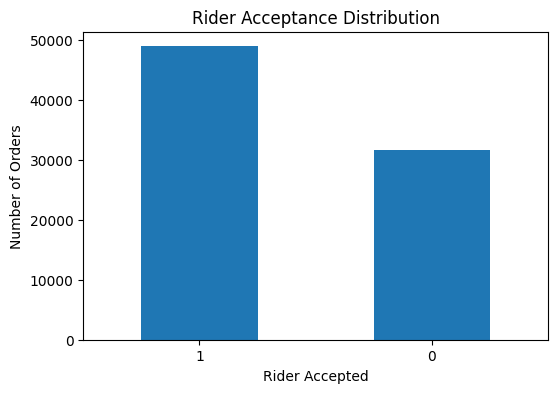

In [206]:
df["rider_accepted"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Rider Acceptance Distribution")
plt.xlabel("Rider Accepted")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [207]:
num_cols = [
    "distance_km",
    "traffic_index",
    "rainfall_mm",
    "item_count",
    "order_amount",
    "order_weight_kg",
    "rider_experience_months",
    "current_rider_load",
    "rider_rating",
    "previous_acceptance_rate",
    "rider_earnings_today",
    "current_incentive",
    "delivery_charge",
    "delivery_time_minutes",
    "historical_delivery_cost",
    "historical_travel_time"
]

df.groupby("rider_accepted")[num_cols].mean().T

rider_accepted,0,1
distance_km,3.687569,2.090605
traffic_index,0.547235,0.567478
rainfall_mm,1.209774,1.045554
item_count,5.166983,5.131181
order_amount,168.195927,166.118321
order_weight_kg,2.524206,2.427146
rider_experience_months,15.408952,15.451930
current_rider_load,1.500127,1.508486
rider_rating,4.416760,4.463241
previous_acceptance_rate,0.692259,0.728115


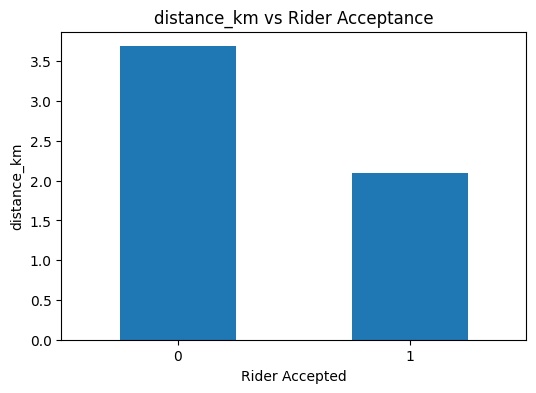

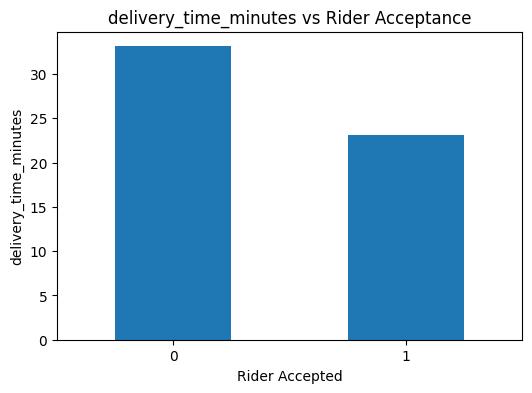

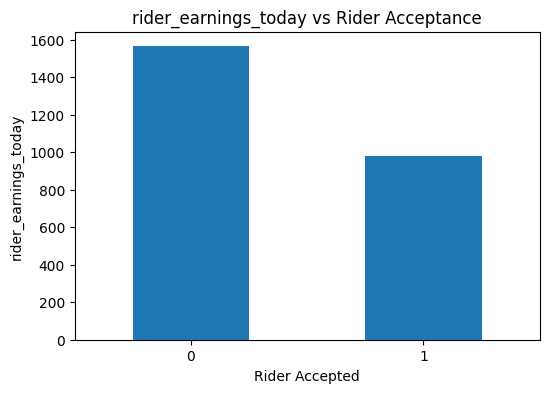

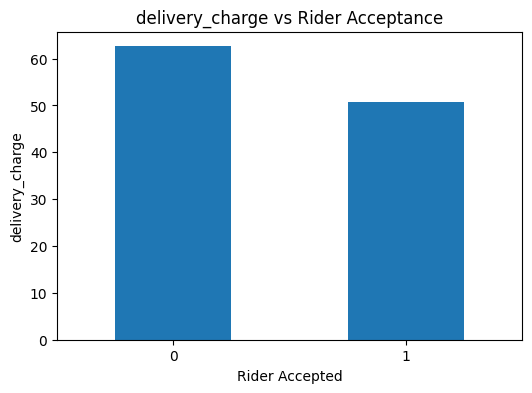

In [208]:
features = [
    "distance_km",
    "delivery_time_minutes",
    "rider_earnings_today",
    "delivery_charge"
]

for col in features:
    df.groupby("rider_accepted")[col].mean().plot(
        kind="bar",
        figsize=(6, 4)
    )

    plt.title(f"{col} vs Rider Acceptance")
    plt.xlabel("Rider Accepted")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.show()

In [209]:
categorical_cols = [
    "city",
    "vehicle_type",
    "demand_level",
    "road_type",
    "membership_type"
]

for col in categorical_cols:
    print(f"\n{'='*50}")
    print(f"{col.upper()} vs RIDER ACCEPTANCE")
    print("="*50)

    result = pd.crosstab(
        df[col],
        df["rider_accepted"],
        normalize="index"
    ) * 100

    print(result.round(2))


CITY vs RIDER ACCEPTANCE
rider_accepted      0      1
city                        
bengaluru       39.92  60.08
chennai         40.07  59.93
coimbatore      37.42  62.58
delhi           38.43  61.57
hyderabad       39.18  60.82
madurai         37.44  62.56
mumbai          40.41  59.59
mysore          36.64  63.36
secunderabad    38.68  61.32
trichy          36.62  63.38

VEHICLE_TYPE vs RIDER ACCEPTANCE
rider_accepted      0      1
vehicle_type                
bicycle         65.68  34.32
bike            29.59  70.41
ev_bike         47.26  52.74
scooter         47.44  52.56

DEMAND_LEVEL vs RIDER ACCEPTANCE
rider_accepted      0      1
demand_level                
high            34.68  65.32
low             42.49  57.51
medium          38.40  61.60

ROAD_TYPE vs RIDER ACCEPTANCE
rider_accepted      0      1
road_type                   
arterial        39.21  60.79
highway         39.20  60.80
narrow_lane     39.40  60.60
residential     39.28  60.72

MEMBERSHIP_TYPE vs RIDER ACCEPTAN

In [210]:
df["order_placed_at"].dt.hour.value_counts().sort_index()

order_placed_at
0      443
1      250
2      164
3      168
4      253
5      654
6     1239
7     2072
8     3936
9     4821
10    3910
11    3439
12    5497
13    5922
14    4353
15    3003
16    2873
17    3899
18    6329
19    7988
20    7568
21    5974
22    3863
23    1898
Name: count, dtype: int64

In [211]:
hour_acceptance = pd.crosstab(
    df["hour"],
    df["rider_accepted"],
    normalize="index"
) * 100

hour_acceptance.round(2)


rider_accepted,0,1
hour,,
0,20.77,79.23
1,22.80,77.20
2,18.29,81.71
3,26.19,73.81
4,24.90,75.10
5,29.82,70.18
6,31.56,68.44
7,33.06,66.94
8,26.27,73.73


In [212]:
flag_cols = [
    "peak_hour_flag",
    "weekend_flag",
    "festival_day_flag"
]

for col in flag_cols:
    print(f"\n{'='*45}")
    print(col.upper())
    print("="*45)

    result = pd.crosstab(
        df[col],
        df["rider_accepted"],
        normalize="index"
    ) * 100

    print(result.round(2))


PEAK_HOUR_FLAG
rider_accepted      0      1
peak_hour_flag              
0               44.80  55.20
1               34.11  65.89

WEEKEND_FLAG
rider_accepted      0      1
weekend_flag                
0               38.37  61.63
1               41.45  58.55

FESTIVAL_DAY_FLAG
rider_accepted         0      1
festival_day_flag              
0                  39.91  60.09
1                  23.23  76.77


In [213]:
df["festival_day_flag"].value_counts()

festival_day_flag
0    77404
1     3112
Name: count, dtype: int64

In [214]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

correlation = (
    df[numeric_cols]
    .corr()["rider_accepted"]
    .sort_values(ascending=False)
)

correlation

rider_accepted              1.000000
previous_acceptance_rate    0.123164
peak_hour_flag              0.109409
rider_rating                0.075444
festival_day_flag           0.065825
traffic_index               0.057632
city_tier                   0.018727
historical_delivery_cost    0.009371
historical_travel_time      0.008927
store_lon                   0.003746
customer_lon                0.003731
current_rider_load          0.003650
rider_experience_months     0.002141
store_lat                   0.000389
customer_lat                0.000373
item_count                 -0.005606
order_amount               -0.006837
order_weight_kg            -0.019469
rainfall_mm                -0.025741
weekday                    -0.026024
weekend_flag               -0.028582
hour                       -0.122375
current_incentive          -0.251109
delivery_charge            -0.290489
travel_time_diff           -0.296583
rider_earnings_today       -0.392273
delivery_time_minutes      -0.418839
d

In [215]:
features = [
    "distance_km",
    "traffic_index",
    "rainfall_mm",
    "hour",
    "weekday",
    "peak_hour_flag",
    "weekend_flag",
    "festival_day_flag",
    "item_count",
    "order_amount",
    "order_weight_kg",
    "membership_type",
    "demand_level",
    "vehicle_type",
    "rider_experience_months",
    "current_rider_load",
    "rider_rating",
    "previous_acceptance_rate",
    "rider_earnings_today",
    "current_incentive",
    "delivery_charge",
    "city",
    "road_type",
    "city_tier"
]

X = df[features]
y = df["rider_accepted"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (80516, 24)
y shape: (80516,)


In [216]:
df.isna().sum()

order_id                    0
order_placed_at             0
store_id                    0
store_lat                   0
store_lon                   0
delivery_zone               0
city                        0
city_tier                   0
customer_lat                0
customer_lon                0
distance_km                 0
road_type                   0
traffic_index               0
rainfall_mm                 0
weather_condition           0
hour                        0
weekday                     0
peak_hour_flag              0
weekend_flag                0
festival_day_flag           0
item_count                  0
order_amount                0
order_weight_kg             0
membership_type             0
demand_level                0
vehicle_type                0
rider_experience_months     0
current_rider_load          0
rider_rating                0
previous_acceptance_rate    0
rider_earnings_today        0
current_incentive           0
delivery_charge             0
delivery_t

In [217]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nInfinite values in X:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nMissing values in y:")
print(y.isna().sum())

print("\nInfinite values in y:")
print(np.isinf(y).sum())

X shape: (80516, 24)
y shape: (80516,)

Missing values in X:
0

Infinite values in X:
0

Missing values in y:
0

Infinite values in y:
0


In [218]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (64412, 24)
X_test : (16104, 24)
y_train: (64412,)
y_test : (16104,)


In [219]:
categorical_cols = [
    "membership_type",
    "demand_level",
    "vehicle_type",
    "city",
    "road_type"
]

numeric_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numerical:", numeric_cols)

Categorical: ['membership_type', 'demand_level', 'vehicle_type', 'city', 'road_type']
Numerical: ['distance_km', 'traffic_index', 'rainfall_mm', 'hour', 'weekday', 'peak_hour_flag', 'weekend_flag', 'festival_day_flag', 'item_count', 'order_amount', 'order_weight_kg', 'rider_experience_months', 'current_rider_load', 'rider_rating', 'previous_acceptance_rate', 'rider_earnings_today', 'current_incentive', 'delivery_charge', 'city_tier']


In [220]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [221]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

In [222]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [223]:
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [224]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.8605315449577745
Precision: 0.8703430649759166
Recall   : 0.9052244146815254
F1 Score : 0.8874411145634961
ROC-AUC  : 0.9393135089424715

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.79      0.82      6323
           1       0.87      0.91      0.89      9781

    accuracy                           0.86     16104
   macro avg       0.86      0.85      0.85     16104
weighted avg       0.86      0.86      0.86     16104



In [225]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [226]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [227]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [228]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.8917039244908097
Precision: 0.9004484304932735
Recall   : 0.9238319190266844
F1 Score : 0.9119903108599112
ROC-AUC  : 0.9613666611782375

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      6323
           1       0.90      0.92      0.91      9781

    accuracy                           0.89     16104
   macro avg       0.89      0.88      0.89     16104
weighted avg       0.89      0.89      0.89     16104



In [229]:
rf = rf_model.named_steps["model"]
preprocessor_fitted = rf_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

importance.head(20)

num__distance_km                 0.237930
num__rider_earnings_today        0.220202
num__delivery_charge             0.068273
num__current_incentive           0.065154
num__previous_acceptance_rate    0.044534
num__traffic_index               0.034625
cat__vehicle_type_bike           0.031282
num__rider_rating                0.031115
num__order_weight_kg             0.027396
num__rider_experience_months     0.026614
num__order_amount                0.024918
num__hour                        0.024015
num__item_count                  0.016971
cat__vehicle_type_bicycle        0.014206
num__weekday                     0.013169
num__rainfall_mm                 0.012560
num__peak_hour_flag              0.012552
num__current_rider_load          0.010011
cat__vehicle_type_scooter        0.007657
num__festival_day_flag           0.005137
dtype: float64

[[5324  999]
 [ 745 9036]]


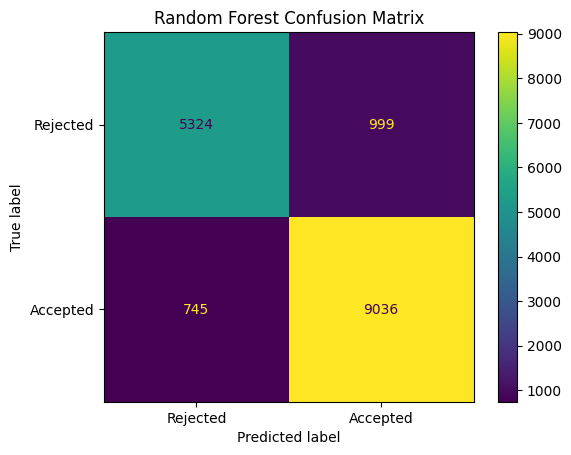

In [230]:

cm = confusion_matrix(y_test, rf_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Accepted"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [231]:
rf_tuned = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [232]:
rf_tuned.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [233]:
tuned_pred = rf_tuned.predict(X_test)
tuned_prob = rf_tuned.predict_proba(X_test)[:, 1]

In [234]:
print("Accuracy :", accuracy_score(y_test, tuned_pred))
print("Precision:", precision_score(y_test, tuned_pred))
print("Recall   :", recall_score(y_test, tuned_pred))
print("F1 Score :", f1_score(y_test, tuned_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_prob))

Accuracy : 0.8892821659215102
Precision: 0.8949239581275923
Recall   : 0.9264901339331356
F1 Score : 0.9104335158486965
ROC-AUC  : 0.959991082906382


In [235]:
print("Accuracy :", accuracy_score(y_test, tuned_pred),"|",accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, tuned_pred),"|", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, tuned_pred),"|", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, tuned_pred),"|", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_prob),"|", roc_auc_score(y_test, rf_prob))


Accuracy : 0.8892821659215102 | 0.8917039244908097
Precision: 0.8949239581275923 | 0.9004484304932735
Recall   : 0.9264901339331356 | 0.9238319190266844
F1 Score : 0.9104335158486965 | 0.9119903108599112
ROC-AUC  : 0.959991082906382 | 0.9613666611782375


In [236]:
rf_train_pred = rf_model.predict(X_train)
rf_train_prob = rf_model.predict_proba(X_train)[:, 1]

print("TRAIN")
print("Accuracy :", accuracy_score(y_train, rf_train_pred))
print("F1 Score :", f1_score(y_train, rf_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, rf_train_prob))

print("\nTEST")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

TRAIN
Accuracy : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

TEST
Accuracy : 0.8917039244908097
F1 Score : 0.9119903108599112
ROC-AUC  : 0.9613666611782375


In [237]:
rf_regularized = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=4,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [238]:
rf_regularized.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [239]:
reg_pred = rf_regularized.predict(X_test)
reg_prob = rf_regularized.predict_proba(X_test)[:, 1]

In [240]:
print("TEST")
print("Accuracy :", accuracy_score(y_test, reg_pred))
print("Precision:", precision_score(y_test, reg_pred))
print("Recall   :", recall_score(y_test, reg_pred))
print("F1 Score :", f1_score(y_test, reg_pred))
print("ROC-AUC  :", roc_auc_score(y_test, reg_prob))

TEST
Accuracy : 0.8851838052657724
Precision: 0.8860981308411215
Recall   : 0.9305796953276761
F1 Score : 0.9077943449857877
ROC-AUC  : 0.9567772231803751


In [241]:
reg_train_pred = rf_regularized.predict(X_train)
reg_train_prob = rf_regularized.predict_proba(X_train)[:, 1]

print("\nTRAIN")
print("Accuracy :", accuracy_score(y_train, reg_train_pred))
print("F1 Score :", f1_score(y_train, reg_train_pred))
print("ROC-AUC  :", roc_auc_score(y_train, reg_train_prob))


TRAIN
Accuracy : 0.9182916226790039
F1 Score : 0.934249484664876
ROC-AUC  : 0.9776343814531155


In [242]:
print("TEST")
print("Accuracy :", accuracy_score(y_test, reg_pred))
print("Precision:", precision_score(y_test, reg_pred))
print("Recall   :", recall_score(y_test, reg_pred))
print("F1 Score :", f1_score(y_test, reg_pred))
print("ROC-AUC  :", roc_auc_score(y_test, reg_prob))


TEST
Accuracy : 0.8851838052657724
Precision: 0.8860981308411215
Recall   : 0.9305796953276761
F1 Score : 0.9077943449857877
ROC-AUC  : 0.9567772231803751


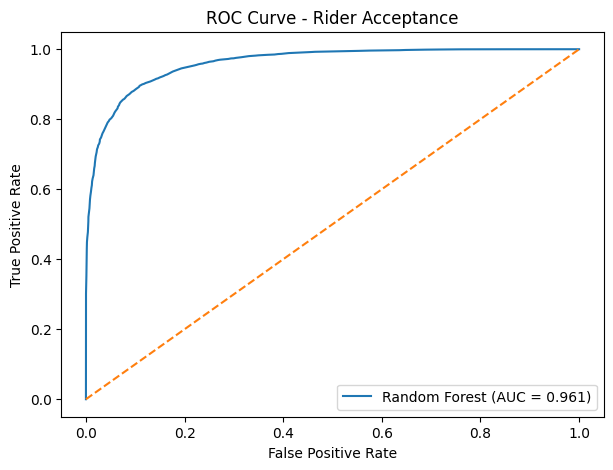

In [243]:

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Rider Acceptance")
plt.legend()
plt.show()

In [244]:
# Get feature importance from the final Random Forest
rf = rf_model.named_steps["model"]
preprocessor_fitted = rf_model.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Remove num__/cat__ prefixes
importance_df["original_feature"] = (
    importance_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Group one-hot encoded features back to their original feature
overall_importance = (
    importance_df
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

print(overall_importance)

original_feature
distance_km                 0.237930
rider_earnings_today        0.220202
delivery_charge             0.068273
current_incentive           0.065154
previous_acceptance_rate    0.044534
traffic_index               0.034625
vehicle_type_bike           0.031282
rider_rating                0.031115
order_weight_kg             0.027396
rider_experience_months     0.026614
order_amount                0.024918
hour                        0.024015
item_count                  0.016971
vehicle_type_bicycle        0.014206
weekday                     0.013169
rainfall_mm                 0.012560
peak_hour_flag              0.012552
current_rider_load          0.010011
vehicle_type_scooter        0.007657
festival_day_flag           0.005137
vehicle_type_ev_bike        0.004500
demand_level_low            0.004276
membership_type_None        0.004272
road_type_arterial          0.004260
road_type_residential       0.004207
demand_level_high           0.003957
membership_type_Pass 

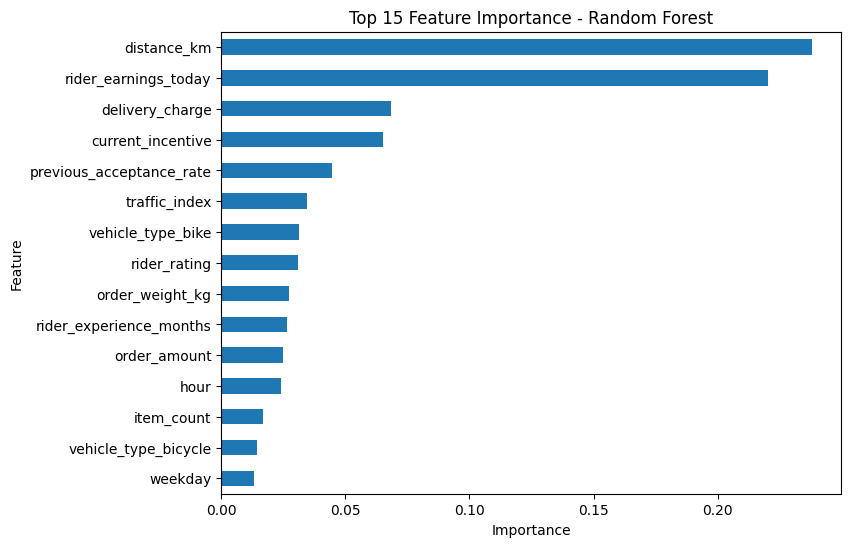

In [245]:
top_features = overall_importance.head(15).sort_values()

plt.figure(figsize=(8, 6))

top_features.plot(kind="barh")

plt.title("Top 15 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

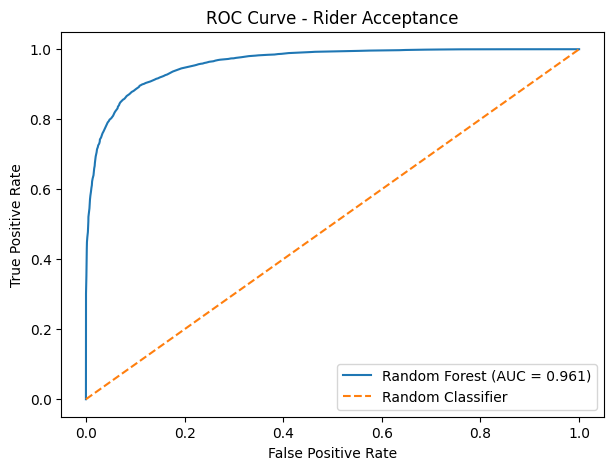

In [246]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Rider Acceptance")
plt.legend()
plt.show()

In [247]:
import joblib

joblib.dump(
    rf_model,
    "rider_acceptance_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [248]:
import os

print(os.path.getsize("rider_acceptance_model.pkl") / (1024 * 1024), "MB")

209.60086250305176 MB


In [249]:
import joblib

loaded_model = joblib.load("rider_acceptance_model.pkl")

loaded_pred = loaded_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, loaded_pred))
print("Same predictions:", (loaded_pred == rf_pred).all())

Accuracy: 0.8917039244908097
Same predictions: True


In [250]:
new_order = pd.DataFrame([{
    "distance_km": 2.5,
    "traffic_index": 0.60,
    "rainfall_mm": 0.0,
    "hour": 19,
    "weekday": 4,
    "peak_hour_flag": 1,
    "weekend_flag": 0,
    "festival_day_flag": 0,
    "item_count": 4,
    "order_amount": 180.0,
    "order_weight_kg": 2.0,
    "membership_type": "Pass",
    "demand_level": "high",
    "vehicle_type": "bike",
    "rider_experience_months": 15.0,
    "current_rider_load": 1,
    "rider_rating": 4.5,
    "previous_acceptance_rate": 0.75,
    "rider_earnings_today": 800.0,
    "current_incentive": 45.0,
    "delivery_charge": 50.0,
    "city": "bengaluru",
    "road_type": "arterial",
    "city_tier": 1
}])

In [251]:
prediction = loaded_model.predict(new_order)[0]

probability = loaded_model.predict_proba(new_order)[0][1]

print("Acceptance Probability:", round(probability * 100, 2), "%")
print(
    "Prediction:",
    "ACCEPTED" if prediction == 1 else "REJECTED"
)

Acceptance Probability: 98.0 %
Prediction: ACCEPTED


In [252]:
features = [
    "distance_km",
    "traffic_index",
    "rainfall_mm",
    "hour",
    "weekday",
    "peak_hour_flag",
    "weekend_flag",
    "festival_day_flag",
    "item_count",
    "order_amount",
    "order_weight_kg",
    "membership_type",
    "demand_level",
    "vehicle_type",
    "rider_experience_months",
    "current_rider_load",
    "rider_rating",
    "previous_acceptance_rate",
    "rider_earnings_today",
    "current_incentive",
    "delivery_charge",
    "city",
    "road_type",
    "city_tier"
]

print("Number of features:", len(features))

Number of features: 24


In [253]:
def predict_rider_acceptance(order_data):

    order_df = pd.DataFrame([order_data])

    prediction = loaded_model.predict(order_df)[0]
    probability = loaded_model.predict_proba(order_df)[0][1]

    result = {
        "acceptance_probability": round(probability * 100, 2),
        "prediction": "ACCEPTED" if prediction == 1 else "REJECTED"
    }

    return result

In [254]:
result = predict_rider_acceptance({
    "distance_km": 2.5,
    "traffic_index": 0.60,
    "rainfall_mm": 0.0,
    "hour": 19,
    "weekday": 4,
    "peak_hour_flag": 1,
    "weekend_flag": 0,
    "festival_day_flag": 0,
    "item_count": 4,
    "order_amount": 180.0,
    "order_weight_kg": 2.0,
    "membership_type": "Pass",
    "demand_level": "high",
    "vehicle_type": "bike",
    "rider_experience_months": 15.0,
    "current_rider_load": 1,
    "rider_rating": 4.5,
    "previous_acceptance_rate": 0.75,
    "rider_earnings_today": 800.0,
    "current_incentive": 45.0,
    "delivery_charge": 50.0,
    "city": "bengaluru",
    "road_type": "arterial",
    "city_tier": 1
})

print(result)

{'acceptance_probability': np.float64(98.0), 'prediction': 'ACCEPTED'}


In [255]:
def predict_rider_acceptance(order_data):

    order_df = pd.DataFrame([order_data])

    prediction = loaded_model.predict(order_df)[0]
    probability = loaded_model.predict_proba(order_df)[0][1]

    return {
        "acceptance_probability": round(float(probability) * 100, 2),
        "prediction": "ACCEPTED" if prediction == 1 else "REJECTED"
    }

In [256]:
result = predict_rider_acceptance({
    "distance_km": 2.5,
    "traffic_index": 0.60,
    "rainfall_mm": 0.0,
    "hour": 19,
    "weekday": 4,
    "peak_hour_flag": 1,
    "weekend_flag": 0,
    "festival_day_flag": 0,
    "item_count": 4,
    "order_amount": 180.0,
    "order_weight_kg": 2.0,
    "membership_type": "Pass",
    "demand_level": "high",
    "vehicle_type": "bike",
    "rider_experience_months": 15.0,
    "current_rider_load": 1,
    "rider_rating": 4.5,
    "previous_acceptance_rate": 0.75,
    "rider_earnings_today": 800.0,
    "current_incentive": 45.0,
    "delivery_charge": 50.0,
    "city": "bengaluru",
    "road_type": "arterial",
    "city_tier": 1
})

print(result)

{'acceptance_probability': 98.0, 'prediction': 'ACCEPTED'}


In [258]:
print("Model type:", type(loaded_model))

try:
    print("\nExpected columns:")
    print(loaded_model.feature_names_in_)
except:
    print("\nPipeline steps:")
    print(loaded_model.named_steps)

Model type: <class 'sklearn.pipeline.Pipeline'>

Expected columns:
['distance_km' 'traffic_index' 'rainfall_mm' 'hour' 'weekday'
 'peak_hour_flag' 'weekend_flag' 'festival_day_flag' 'item_count'
 'order_amount' 'order_weight_kg' 'membership_type' 'demand_level'
 'vehicle_type' 'rider_experience_months' 'current_rider_load'
 'rider_rating' 'previous_acceptance_rate' 'rider_earnings_today'
 'current_incentive' 'delivery_charge' 'city' 'road_type' 'city_tier']


In [259]:
import joblib

loaded_model = joblib.load("rider_acceptance_model.pkl")

print(type(loaded_model))

<class 'sklearn.pipeline.Pipeline'>


In [260]:
try:
    print(loaded_model.feature_names_in_)
except:
    print("feature_names_in_ not available")

['distance_km' 'traffic_index' 'rainfall_mm' 'hour' 'weekday'
 'peak_hour_flag' 'weekend_flag' 'festival_day_flag' 'item_count'
 'order_amount' 'order_weight_kg' 'membership_type' 'demand_level'
 'vehicle_type' 'rider_experience_months' 'current_rider_load'
 'rider_rating' 'previous_acceptance_rate' 'rider_earnings_today'
 'current_incentive' 'delivery_charge' 'city' 'road_type' 'city_tier']


In [264]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(
    title="Rider Acceptance Prediction API",
    description="Predict whether a rider will accept a delivery order",
    version="1.0"
)

# Load trained pipeline
model = joblib.load("rider_acceptance_model.pkl")


class OrderData(BaseModel):
    distance_km: float
    traffic_index: float
    rainfall_mm: float
    hour: int
    weekday: int
    peak_hour_flag: int
    weekend_flag: int
    festival_day_flag: int
    item_count: int
    order_amount: float
    order_weight_kg: float
    membership_type: str
    demand_level: str
    vehicle_type: str
    rider_experience_months: float
    current_rider_load: int
    rider_rating: float
    previous_acceptance_rate: float
    rider_earnings_today: float
    current_incentive: float
    delivery_charge: float
    city: str
    road_type: str
    city_tier: int


@app.get("/")
def home():
    return {
        "message": "Rider Acceptance Prediction API is running"
    }


@app.post("/predict")
def predict(data: OrderData):

    input_data = pd.DataFrame([data.model_dump()])

    prediction = model.predict(input_data)[0]

    probability = model.predict_proba(input_data)[0][1]

    return {
        "prediction": "ACCEPTED" if prediction == 1 else "REJECTED",
        "acceptance_probability": round(float(probability) * 100, 2)
    }

ModuleNotFoundError: No module named 'fastapi'

In [ ]:
import nest_asyncio

nest_asyncio.apply()

print("FastAPI app created successfully")

FastAPI app created successfully


In [ ]:
%%writefile app.py

from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

app = FastAPI(
    title="Rider Acceptance Prediction API",
    description="Predict whether a rider will accept a delivery order",
    version="1.0"
)

# Load trained ML pipeline
model = joblib.load("rider_acceptance_model.pkl")


class OrderData(BaseModel):
    distance_km: float
    traffic_index: float
    rainfall_mm: float
    hour: int
    weekday: int
    peak_hour_flag: int
    weekend_flag: int
    festival_day_flag: int
    item_count: int
    order_amount: float
    order_weight_kg: float
    membership_type: str
    demand_level: str
    vehicle_type: str
    rider_experience_months: float
    current_rider_load: int
    rider_rating: float
    previous_acceptance_rate: float
    rider_earnings_today: float
    current_incentive: float
    delivery_charge: float
    city: str
    road_type: str
    city_tier: int


@app.get("/")
def home():
    return {
        "message": "Rider Acceptance Prediction API is running",
        "status": "success"
    }


@app.post("/predict")
def predict(data: OrderData):

    # Convert request data to DataFrame
    input_data = pd.DataFrame([data.model_dump()])

    # Prediction
    prediction = model.predict(input_data)[0]

    # Probability of acceptance
    probability = model.predict_proba(input_data)[0][1]

    return {
        "prediction": "ACCEPTED" if prediction == 1 else "REJECTED",
        "acceptance_probability": round(float(probability) * 100, 2)
    }

Writing app.py


In [ ]:
!ls -lh app.py rider_acceptance_model.pkl

-rw-r--r-- 1 root root 1.5K Aug 20 07:20 app.py
-rw-r--r-- 1 root root 210M Aug 20 07:19 rider_acceptance_model.pkl


In [ ]:
!fuser -k 8000/tcp 2>/dev/null || true

In [ ]:
import subprocess
import time

process = subprocess.Popen(
    [
        "uvicorn",
        "app:app",
        "--host", "127.0.0.1",
        "--port", "8000"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(3)

print("FastAPI process started")

FastAPI process started


In [ ]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/",
    timeout=10
)

print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'message': 'Rider Acceptance Prediction API is running', 'status': 'success'}


In [ ]:
import requests

test_order = {
    "distance_km": 2.5,
    "traffic_index": 0.60,
    "rainfall_mm": 0.0,
    "hour": 19,
    "weekday": 4,
    "peak_hour_flag": 1,
    "weekend_flag": 0,
    "festival_day_flag": 0,
    "item_count": 4,
    "order_amount": 180.0,
    "order_weight_kg": 2.0,
    "membership_type": "Pass",
    "demand_level": "high",
    "vehicle_type": "bike",
    "rider_experience_months": 15.0,
    "current_rider_load": 1,
    "rider_rating": 4.5,
    "previous_acceptance_rate": 0.75,
    "rider_earnings_today": 800.0,
    "current_incentive": 45.0,
    "delivery_charge": 50.0,
    "city": "bengaluru",
    "road_type": "arterial",
    "city_tier": 1
}

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=test_order,
    timeout=30
)

print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'prediction': 'ACCEPTED', 'acceptance_probability': 98.0}


In [ ]:
test_rejected = {
    "distance_km": 8.0,
    "traffic_index": 0.90,
    "rainfall_mm": 15.0,
    "hour": 22,
    "weekday": 5,
    "peak_hour_flag": 0,
    "weekend_flag": 1,
    "festival_day_flag": 0,
    "item_count": 6,
    "order_amount": 120.0,
    "order_weight_kg": 5.0,
    "membership_type": "None",
    "demand_level": "low",
    "vehicle_type": "bicycle",
    "rider_experience_months": 5.0,
    "current_rider_load": 3,
    "rider_rating": 3.5,
    "previous_acceptance_rate": 0.40,
    "rider_earnings_today": 1800.0,
    "current_incentive": 10.0,
    "delivery_charge": 30.0,
    "city": "mumbai",
    "road_type": "narrow_lane",
    "city_tier": 1
}

response = requests.post(
    "http://127.0.0.1:8000/predict",
    json=test_rejected,
    timeout=30
)

print("Status:", response.status_code)
print("Response:", response.json())

Status: 200
Response: {'prediction': 'REJECTED', 'acceptance_probability': 20.0}


In [ ]:
import requests

response = requests.get(
    "http://127.0.0.1:8000/docs",
    timeout=10
)

print("Status:", response.status_code)
print("Swagger UI available:", response.status_code == 200)

Status: 200
Swagger UI available: True


In [ ]:
!pip install streamlit plotly scipy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 77.0 MB/s eta 0:00:00


In [ ]:
!pkill -9 -f streamlit
!pkill -9 -f uvicorn
import time
time.sleep(2)
!ps aux | grep -E "streamlit|uvicorn"

root        4223 14.2  0.0      0     0 ?        Z    07:20   0:03 [uvicorn] <defunct>
root        4361  0.0  0.0   7372  3600 ?        S    07:20   0:00 /bin/bash -c ps aux | grep -E "streamlit|uvicorn"
root        4363  0.0  0.0   6612  2376 ?        S    07:20   0:00 grep -E streamlit|uvicorn


In [ ]:
!ls *.py *.pkl 2>/dev/null

app.py	rider_acceptance_model.pkl


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rider_acceptance_model (1).pkl to rider_acceptance_model (1).pkl


In [ ]:
!pip install streamlit plotly scipy fastapi uvicorn -q

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import random
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm

st.set_page_config(
    page_title="Zepto Rider Acceptance Predictor",
    page_icon="🛵",
    layout="wide"
)

@st.cache_resource
def load_model():
    return joblib.load("rider_acceptance_model.pkl")

model = load_model()

CITIES = ["bengaluru", "chennai", "coimbatore", "delhi", "hyderabad",
          "madurai", "mumbai", "mysore", "secunderabad", "trichy"]
CITY_TIER = {
    "bengaluru": 1, "chennai": 1, "mumbai": 1, "delhi": 1, "hyderabad": 1,
    "coimbatore": 2, "mysore": 2, "secunderabad": 2, "madurai": 3, "trichy": 3,
}
ROAD_TYPES = ["arterial", "residential", "narrow_lane", "highway"]
DEMAND_LEVELS = ["low", "medium", "high"]
VEHICLE_TYPES = ["bike", "scooter", "ev_bike", "bicycle"]
MEMBERSHIP_TYPES = ["None", "Pass", "passplus"]

REPORTED_METRICS = {
    "accuracy": 0.8917039244908097,
    "precision": 0.9004484304932735,
    "recall": 0.9238319190266844,
    "f1": 0.9119903108599112,
    "roc_auc": 0.9613666611782375,
}
CONF_MATRIX = {"TN": 5322, "FP": 1001, "FN": 745, "TP": 9036}

st.sidebar.title("🛵 Zepto Delivery Intelligence")
page = st.sidebar.radio(
    "Go to",
    ["Predict Rider Acceptance", "Model Performance", "Feature Importance",
     "EDA / Data Insights", "Sample Order Data"]
)

st.title("🛵 Rider Acceptance Prediction")
st.caption("Zepto Smart Commerce AI Platform · Module 1.3 — ML Delivery Intelligence Engine")

if page == "Predict Rider Acceptance":

    st.subheader("Enter order & rider conditions")

    with st.form("prediction_form"):
        col1, col2, col3 = st.columns(3)

        with col1:
            st.markdown("**Order details**")
            city = st.selectbox("City", CITIES, index=CITIES.index("bengaluru"))
            road_type = st.selectbox("Road type", ROAD_TYPES, index=0)
            distance_km = st.slider("Distance (km)", 0.1, 15.0, 2.5, 0.1)
            item_count = st.number_input("Item count", min_value=1, max_value=40, value=4)
            order_amount = st.number_input("Order amount (₹)", min_value=0.0, value=180.0, step=10.0)
            order_weight_kg = st.number_input("Order weight (kg)", min_value=0.0, value=2.0, step=0.1)
            delivery_charge = st.number_input("Delivery charge (₹)", min_value=0.0, value=50.0, step=5.0)

        with col2:
            st.markdown("**Timing & conditions**")
            hour = st.slider("Hour of day", 0, 23, 19)
            weekday = st.selectbox(
                "Weekday", options=list(range(7)), index=4,
                format_func=lambda x: ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][x]
            )
            peak_hour_flag = st.checkbox("Peak hour (12–2pm / 7–10pm)", value=True)
            weekend_flag = st.checkbox("Weekend", value=False)
            festival_day_flag = st.checkbox("Festival day", value=False)
            traffic_index = st.slider("Traffic index (0=free, 1=jammed)", 0.0, 1.0, 0.6, 0.05)
            rainfall_mm = st.slider("Rainfall (mm)", 0.0, 80.0, 0.0, 1.0)

        with col3:
            st.markdown("**Rider profile**")
            vehicle_type = st.selectbox("Vehicle type", VEHICLE_TYPES, index=0)
            rider_experience_months = st.number_input("Rider experience (months)", min_value=0.0, value=15.0, step=1.0)
            current_rider_load = st.number_input("Current rider load (active orders)", min_value=0, max_value=10, value=1)
            rider_rating = st.slider("Rider rating", 2.5, 5.0, 4.5, 0.05)
            previous_acceptance_rate = st.slider("Previous acceptance rate", 0.0, 1.0, 0.75, 0.01)
            rider_earnings_today = st.number_input("Rider earnings today (₹)", min_value=0.0, value=800.0, step=50.0)
            current_incentive = st.number_input("Current incentive (₹)", min_value=0.0, value=45.0, step=5.0)
            membership_type = st.selectbox("Customer membership", MEMBERSHIP_TYPES, index=1)
            demand_level = st.selectbox("Demand level", DEMAND_LEVELS, index=2)

        submitted = st.form_submit_button("Predict Acceptance", use_container_width=True)

    if submitted:
        input_row = pd.DataFrame([{
            "distance_km": distance_km,
            "traffic_index": traffic_index,
            "rainfall_mm": rainfall_mm,
            "hour": hour,
            "weekday": weekday,
            "peak_hour_flag": int(peak_hour_flag),
            "weekend_flag": int(weekend_flag),
            "festival_day_flag": int(festival_day_flag),
            "item_count": item_count,
            "order_amount": order_amount,
            "order_weight_kg": order_weight_kg,
            "membership_type": membership_type,
            "demand_level": demand_level,
            "vehicle_type": vehicle_type,
            "rider_experience_months": rider_experience_months,
            "current_rider_load": current_rider_load,
            "rider_rating": rider_rating,
            "previous_acceptance_rate": previous_acceptance_rate,
            "rider_earnings_today": rider_earnings_today,
            "current_incentive": current_incentive,
            "delivery_charge": delivery_charge,
            "city": city,
            "road_type": road_type,
            "city_tier": CITY_TIER[city],
        }])

        prediction = model.predict(input_row)[0]
        probability = model.predict_proba(input_row)[0][1]

        st.divider()
        res_col1, res_col2 = st.columns([1, 2])

        with res_col1:
            if prediction == 1:
                st.success("### ✅ ACCEPTED")
            else:
                st.error("### ❌ REJECTED")
            st.metric("Acceptance probability", f"{probability * 100:.1f}%")

        with res_col2:
            st.progress(min(max(probability, 0.0), 1.0))
            if probability > 0.8:
                st.write("Rider is very likely to accept this order — conditions are favorable.")
            elif probability > 0.5:
                st.write("Rider will likely accept, but the margin is moderate. Consider a small incentive bump.")
            else:
                st.write("Low acceptance likelihood — consider raising the incentive, reassigning, or flagging for manual dispatch.")

        with st.expander("View input sent to model"):
            st.dataframe(input_row.T.rename(columns={0: "value"}), use_container_width=True)

elif page == "Model Performance":

    st.subheader("Held-out test set performance")
    st.caption("Metrics as reported during training (Random Forest, 200 trees, 80/20 stratified split, n=16,104 test orders).")

    m = REPORTED_METRICS
    c1, c2, c3, c4, c5 = st.columns(5)
    c1.metric("Accuracy", f"{m['accuracy']*100:.2f}%")
    c2.metric("Precision", f"{m['precision']*100:.2f}%")
    c3.metric("Recall", f"{m['recall']*100:.2f}%")
    c4.metric("F1 Score", f"{m['f1']*100:.2f}%")
    c5.metric("ROC-AUC", f"{m['roc_auc']:.4f}")

    st.divider()
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("#### Confusion Matrix")
        cm = CONF_MATRIX
        z = [[cm["TN"], cm["FP"]], [cm["FN"], cm["TP"]]]
        fig_cm = go.Figure(data=go.Heatmap(
            z=z,
            x=["Predicted: Rejected", "Predicted: Accepted"],
            y=["Actual: Rejected", "Actual: Accepted"],
            text=z, texttemplate="%{text}",
            colorscale="Blues", showscale=False
        ))
        fig_cm.update_layout(height=400, margin=dict(t=20, b=20))
        st.plotly_chart(fig_cm, use_container_width=True)
        st.caption(f"TN={cm['TN']} · FP={cm['FP']} · FN={cm['FN']} · TP={cm['TP']} (16,104 total test orders)")

    with col2:
        st.markdown("#### ROC Curve")
        target_auc = m["roc_auc"]
        d_prime = norm.ppf(target_auc) * np.sqrt(2)
        fpr = np.linspace(0.001, 0.999, 200)
        tpr = norm.cdf(d_prime + norm.ppf(fpr))
        fig_roc = go.Figure()
        fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"ROC (AUC={target_auc:.3f})",
                                      line=dict(color="#2563eb", width=3)))
        fig_roc.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", name="Random baseline",
                                      line=dict(color="gray", dash="dash")))
        fig_roc.update_layout(xaxis_title="False Positive Rate", yaxis_title="True Positive Rate",
                               height=400, margin=dict(t=20, b=20))
        st.plotly_chart(fig_roc, use_container_width=True)
        st.caption("Curve shape reconstructed to match the reported AUC (binormal model).")

    st.divider()
    st.markdown("#### Classification report")
    report_df = pd.DataFrame({
        "class": ["Rejected (0)", "Accepted (1)"],
        "precision": [0.88, 0.90],
        "recall": [0.84, 0.92],
        "f1-score": [0.86, 0.91],
        "support": [6323, 9781],
    })
    st.dataframe(report_df, use_container_width=True, hide_index=True)

elif page == "Feature Importance":

    st.subheader("What drives the model's decision?")
    st.caption("Feature importances extracted directly from the trained Random Forest.")

    rf = model.named_steps["model"]
    preprocessor = model.named_steps["preprocessor"]
    feature_names = preprocessor.get_feature_names_out()
    importances = rf.feature_importances_

    numeric_feats = preprocessor.transformers_[0][2]
    categorical_feats = preprocessor.transformers_[1][2]
    clean_rows = []
    for fname, imp in zip(feature_names, importances):
        if fname.startswith("num__"):
            clean_rows.append((fname.replace("num__", ""), imp))
        elif fname.startswith("cat__"):
            raw = fname.replace("cat__", "")
            matched = next((c for c in categorical_feats if raw.startswith(c + "_")), raw)
            clean_rows.append((matched, imp))
        else:
            clean_rows.append((fname, imp))
    clean_df = pd.DataFrame(clean_rows, columns=["feature", "importance"])
    overall_importance = clean_df.groupby("feature")["importance"].sum().sort_values(ascending=False)

    top_n = st.slider("Show top N features", 5, len(overall_importance), 15)
    top_features = overall_importance.head(top_n).sort_values()

    fig = px.bar(
        x=top_features.values, y=top_features.index, orientation="h",
        labels={"x": "Importance", "y": "Feature"},
        color=top_features.values, color_continuous_scale="Blues"
    )
    fig.update_layout(height=max(400, top_n * 28), showlegend=False, coloraxis_showscale=False)
    st.plotly_chart(fig, use_container_width=True)

    with st.expander("View full importance table"):
        st.dataframe(overall_importance.reset_index().rename(columns={0: "importance"}),
                     use_container_width=True, hide_index=True)

elif page == "EDA / Data Insights":

    st.subheader("Order & acceptance patterns")
    st.caption("Computed by scoring a large synthetic sample (same schema as training data) through the live model — "
               "useful for spotting where acceptance risk concentrates operationally.")

    @st.cache_data
    def generate_eda_sample(n=3000):
        random.seed(11)
        np.random.seed(11)
        rows = []
        for i in range(n):
            city = random.choice(CITIES)
            hour = random.randint(0, 23)
            peak = 1 if (12 <= hour <= 14 or 19 <= hour <= 22) else 0
            rainfall = round(max(0, np.random.exponential(3) - 1.5), 1)
            rows.append({
                "city": city, "city_tier": CITY_TIER[city],
                "road_type": random.choice(ROAD_TYPES),
                "distance_km": round(np.random.gamma(2.0, 1.4), 2),
                "traffic_index": round(np.random.uniform(0.1, 0.9), 2),
                "rainfall_mm": rainfall,
                "hour": hour, "weekday": random.randint(0, 6),
                "peak_hour_flag": peak, "weekend_flag": random.randint(0, 1),
                "festival_day_flag": 1 if random.random() < 0.05 else 0,
                "item_count": random.randint(1, 15),
                "order_amount": round(random.uniform(80, 900), 2),
                "order_weight_kg": round(random.uniform(0.5, 8), 2),
                "membership_type": random.choice(MEMBERSHIP_TYPES),
                "demand_level": random.choice(DEMAND_LEVELS),
                "vehicle_type": random.choice(VEHICLE_TYPES),
                "rider_experience_months": round(np.random.exponential(14), 1),
                "current_rider_load": random.randint(0, 5),
                "rider_rating": round(np.random.uniform(3.2, 5.0), 2),
                "previous_acceptance_rate": round(np.random.uniform(0.4, 0.98), 2),
                "rider_earnings_today": round(random.uniform(100, 1500), 2),
                "current_incentive": round(random.uniform(10, 80), 2),
                "delivery_charge": round(random.uniform(15, 120), 2),
            })
        eda_df = pd.DataFrame(rows)
        probs = model.predict_proba(eda_df)[:, 1]
        eda_df["accepted"] = (probs > 0.5).astype(int)
        eda_df["acceptance_probability"] = probs
        return eda_df

    eda_df = generate_eda_sample(3000)

    k1, k2, k3 = st.columns(3)
    k1.metric("Sample size", f"{len(eda_df):,}")
    k2.metric("Overall predicted acceptance rate", f"{eda_df['accepted'].mean()*100:.1f}%")
    k3.metric("Avg. acceptance probability", f"{eda_df['acceptance_probability'].mean()*100:.1f}%")

    st.divider()
    row1_col1, row1_col2 = st.columns(2)

    with row1_col1:
        city_rate = eda_df.groupby("city")["accepted"].mean().sort_values(ascending=False) * 100
        fig = px.bar(x=city_rate.index, y=city_rate.values, labels={"x": "City", "y": "Acceptance rate (%)"},
                     title="Acceptance rate by city", color=city_rate.values, color_continuous_scale="Teal")
        fig.update_layout(coloraxis_showscale=False, height=380)
        st.plotly_chart(fig, use_container_width=True)

    with row1_col2:
        demand_rate = eda_df.groupby("demand_level")["accepted"].mean().reindex(DEMAND_LEVELS) * 100
        fig = px.bar(x=demand_rate.index, y=demand_rate.values, labels={"x": "Demand level", "y": "Acceptance rate (%)"},
                     title="Acceptance rate by demand level", color=demand_rate.values, color_continuous_scale="Oranges")
        fig.update_layout(coloraxis_showscale=False, height=380)
        st.plotly_chart(fig, use_container_width=True)

    row2_col1, row2_col2 = st.columns(2)

    with row2_col1:
        vehicle_rate = eda_df.groupby("vehicle_type")["accepted"].mean().sort_values(ascending=False) * 100
        fig = px.bar(x=vehicle_rate.index, y=vehicle_rate.values, labels={"x": "Vehicle type", "y": "Acceptance rate (%)"},
                     title="Acceptance rate by vehicle type", color=vehicle_rate.values, color_continuous_scale="Purples")
        fig.update_layout(coloraxis_showscale=False, height=380)
        st.plotly_chart(fig, use_container_width=True)

    with row2_col2:
        eda_df["rain_bucket"] = pd.cut(eda_df["rainfall_mm"], bins=[-0.1, 0, 5, 15, 100],
                                        labels=["No rain", "Light (0-5mm)", "Moderate (5-15mm)", "Heavy (15mm+)"])
        rain_rate = eda_df.groupby("rain_bucket", observed=True)["accepted"].mean() * 100
        fig = px.bar(x=rain_rate.index.astype(str), y=rain_rate.values, labels={"x": "Rainfall", "y": "Acceptance rate (%)"},
                     title="Acceptance rate by rainfall", color=rain_rate.values, color_continuous_scale="Blues")
        fig.update_layout(coloraxis_showscale=False, height=380)
        st.plotly_chart(fig, use_container_width=True)

    st.divider()
    row3_col1, row3_col2 = st.columns(2)

    with row3_col1:
        fig = px.histogram(eda_df, x="acceptance_probability", nbins=40,
                            title="Distribution of predicted acceptance probability",
                            labels={"acceptance_probability": "Predicted probability"})
        fig.update_layout(height=380)
        st.plotly_chart(fig, use_container_width=True)

    with row3_col2:
        fig = px.scatter(eda_df.sample(600, random_state=1), x="current_incentive", y="acceptance_probability",
                          color="demand_level", opacity=0.6,
                          title="Incentive vs. acceptance probability",
                          labels={"current_incentive": "Incentive (₹)", "acceptance_probability": "Predicted probability"})
        fig.update_layout(height=380)
        st.plotly_chart(fig, use_container_width=True)

    peak_col1, peak_col2 = st.columns(2)
    with peak_col1:
        peak_rate = eda_df.groupby("peak_hour_flag")["accepted"].mean() * 100
        peak_rate.index = ["Off-peak", "Peak hour"]
        fig = px.bar(x=peak_rate.index, y=peak_rate.values, labels={"x": "", "y": "Acceptance rate (%)"},
                     title="Peak hour vs off-peak acceptance", color=peak_rate.values, color_continuous_scale="Reds")
        fig.update_layout(coloraxis_showscale=False, height=350)
        st.plotly_chart(fig, use_container_width=True)

    with peak_col2:
        member_rate = eda_df.groupby("membership_type")["accepted"].mean().reindex(MEMBERSHIP_TYPES) * 100
        fig = px.bar(x=member_rate.index, y=member_rate.values, labels={"x": "Membership", "y": "Acceptance rate (%)"},
                     title="Acceptance rate by customer membership", color=member_rate.values, color_continuous_scale="Greens")
        fig.update_layout(coloraxis_showscale=False, height=350)
        st.plotly_chart(fig, use_container_width=True)

else:
    st.subheader("Sample order data")
    st.caption("A representative sample of orders in the same schema the model was trained on.")

    @st.cache_data
    def generate_sample_orders(n=50):
        random.seed(7)
        np.random.seed(7)
        rows = []
        for i in range(n):
            city = random.choice(CITIES)
            hour = random.randint(0, 23)
            peak = 1 if (12 <= hour <= 14 or 19 <= hour <= 22) else 0
            rows.append({
                "order_id": f"ZPO{100000 + i}",
                "city": city,
                "city_tier": CITY_TIER[city],
                "road_type": random.choice(ROAD_TYPES),
                "distance_km": round(np.random.gamma(2.0, 1.4), 2),
                "traffic_index": round(np.random.uniform(0.1, 0.9), 2),
                "rainfall_mm": round(max(0, np.random.exponential(2) - 1), 1),
                "hour": hour,
                "weekday": random.randint(0, 6),
                "peak_hour_flag": peak,
                "weekend_flag": random.randint(0, 1),
                "festival_day_flag": 1 if random.random() < 0.05 else 0,
                "item_count": random.randint(1, 15),
                "order_amount": round(random.uniform(80, 900), 2),
                "order_weight_kg": round(random.uniform(0.5, 8), 2),
                "membership_type": random.choice(MEMBERSHIP_TYPES),
                "demand_level": random.choice(DEMAND_LEVELS),
                "vehicle_type": random.choice(VEHICLE_TYPES),
                "rider_experience_months": round(np.random.exponential(14), 1),
                "current_rider_load": random.randint(0, 5),
                "rider_rating": round(np.random.uniform(3.2, 5.0), 2),
                "previous_acceptance_rate": round(np.random.uniform(0.4, 0.98), 2),
                "rider_earnings_today": round(random.uniform(100, 1500), 2),
                "current_incentive": round(random.uniform(10, 80), 2),
                "delivery_charge": round(random.uniform(15, 120), 2),
            })
        sample_df = pd.DataFrame(rows)
        preds = model.predict(sample_df.drop(columns=["order_id"]))
        probs = model.predict_proba(sample_df.drop(columns=["order_id"]))[:, 1]
        sample_df["predicted_acceptance"] = np.where(preds == 1, "ACCEPTED", "REJECTED")
        sample_df["acceptance_probability_%"] = (probs * 100).round(1)
        return sample_df

    sample_df = generate_sample_orders(50)

    col1, col2, col3 = st.columns(3)
    col1.metric("Sample orders", len(sample_df))
    col2.metric("Predicted acceptance rate", f"{(sample_df['predicted_acceptance']=='ACCEPTED').mean()*100:.1f}%")
    col3.metric("Avg. acceptance probability", f"{sample_df['acceptance_probability_%'].mean():.1f}%")

    st.dataframe(sample_df, use_container_width=True, height=500)

    st.download_button(
        "Download sample as CSV",
        sample_df.to_csv(index=False).encode("utf-8"),
        "sample_orders.csv",
        "text/csv"
    )

st.divider()
st.caption(f"Zepto Smart Commerce AI Platform · Module 1.3 · Model: Random Forest (Accuracy 89.2%, F1 0.912, ROC-AUC 0.96) · {datetime.now().strftime('%Y-%m-%d')}")

Overwriting app.py


In [ ]:
%%writefile api.py

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Literal
import pandas as pd
import joblib

app = FastAPI(
    title="Zepto Delivery Intelligence API",
    description="Module 1.3 — Rider Acceptance Prediction. Predicts whether a delivery "
                 "partner will accept a given order based on order, timing, and rider conditions.",
    version="1.0.0"
)

model = joblib.load("rider_acceptance_model.pkl")

CITIES = ["bengaluru", "chennai", "coimbatore", "delhi", "hyderabad",
          "madurai", "mumbai", "mysore", "secunderabad", "trichy"]
CITY_TIER = {
    "bengaluru": 1, "chennai": 1, "mumbai": 1, "delhi": 1, "hyderabad": 1,
    "coimbatore": 2, "mysore": 2, "secunderabad": 2, "madurai": 3, "trichy": 3,
}


class OrderInput(BaseModel):
    city: Literal["bengaluru", "chennai", "coimbatore", "delhi", "hyderabad",
                   "madurai", "mumbai", "mysore", "secunderabad", "trichy"] = Field(
        "bengaluru", description="Delivery city")
    road_type: Literal["arterial", "residential", "narrow_lane", "highway"] = Field(
        "arterial", description="Road type for the delivery route")
    distance_km: float = Field(2.5, ge=0.1, le=15.0, description="Distance from store to customer in km")
    item_count: int = Field(4, ge=1, le=40, description="Number of items in the order")
    order_amount: float = Field(180.0, ge=0, description="Order value in ₹")
    order_weight_kg: float = Field(2.0, ge=0, description="Total order weight in kg")
    delivery_charge: float = Field(50.0, ge=0, description="Delivery charge in ₹")
    hour: int = Field(19, ge=0, le=23, description="Hour of day (0-23)")
    weekday: int = Field(4, ge=0, le=6, description="Day of week (0=Mon ... 6=Sun)")
    peak_hour_flag: bool = Field(True, description="Whether this falls in a peak hour window")
    weekend_flag: bool = Field(False, description="Whether this is a weekend order")
    festival_day_flag: bool = Field(False, description="Whether this is a festival day")
    traffic_index: float = Field(0.6, ge=0.0, le=1.0, description="Traffic congestion (0=free, 1=jammed)")
    rainfall_mm: float = Field(0.0, ge=0.0, le=80.0, description="Rainfall in mm")
    vehicle_type: Literal["bike", "scooter", "ev_bike", "bicycle"] = Field(
        "bike", description="Rider's vehicle type")
    rider_experience_months: float = Field(15.0, ge=0, description="Rider's experience in months")
    current_rider_load: int = Field(1, ge=0, le=10, description="Rider's current active order count")
    rider_rating: float = Field(4.5, ge=2.5, le=5.0, description="Rider's rating")
    previous_acceptance_rate: float = Field(0.75, ge=0.0, le=1.0, description="Rider's historical acceptance rate")
    rider_earnings_today: float = Field(800.0, ge=0, description="Rider's earnings so far today in ₹")
    current_incentive: float = Field(45.0, ge=0, description="Current incentive offered for this order in ₹")
    membership_type: Literal["None", "Pass", "passplus"] = Field(
        "Pass", description="Customer's membership tier")
    demand_level: Literal["low", "medium", "high"] = Field(
        "high", description="Current demand level in the zone")

    class Config:
        json_schema_extra = {
            "example": {
                "city": "bengaluru", "road_type": "arterial", "distance_km": 2.5,
                "item_count": 4, "order_amount": 180.0, "order_weight_kg": 2.0,
                "delivery_charge": 50.0, "hour": 19, "weekday": 4,
                "peak_hour_flag": True, "weekend_flag": False, "festival_day_flag": False,
                "traffic_index": 0.6, "rainfall_mm": 0.0, "vehicle_type": "bike",
                "rider_experience_months": 15.0, "current_rider_load": 1, "rider_rating": 4.5,
                "previous_acceptance_rate": 0.75, "rider_earnings_today": 800.0,
                "current_incentive": 45.0, "membership_type": "Pass", "demand_level": "high"
            }
        }


class PredictionOutput(BaseModel):
    prediction: Literal["ACCEPTED", "REJECTED"]
    acceptance_probability: float
    model_version: str = "random_forest_v1"


@app.get("/health")
def health():
    """Service and model-load status."""
    return {"status": "ok", "model_loaded": model is not None}


@app.post("/predict-rider-acceptance", response_model=PredictionOutput)
def predict_rider_acceptance(order: OrderInput):
    """Predict whether a delivery partner will accept this order, with probability."""
    try:
        row = pd.DataFrame([{
            "distance_km": order.distance_km,
            "traffic_index": order.traffic_index,
            "rainfall_mm": order.rainfall_mm,
            "hour": order.hour,
            "weekday": order.weekday,
            "peak_hour_flag": int(order.peak_hour_flag),
            "weekend_flag": int(order.weekend_flag),
            "festival_day_flag": int(order.festival_day_flag),
            "item_count": order.item_count,
            "order_amount": order.order_amount,
            "order_weight_kg": order.order_weight_kg,
            "membership_type": order.membership_type,
            "demand_level": order.demand_level,
            "vehicle_type": order.vehicle_type,
            "rider_experience_months": order.rider_experience_months,
            "current_rider_load": order.current_rider_load,
            "rider_rating": order.rider_rating,
            "previous_acceptance_rate": order.previous_acceptance_rate,
            "rider_earnings_today": order.rider_earnings_today,
            "current_incentive": order.current_incentive,
            "delivery_charge": order.delivery_charge,
            "city": order.city,
            "road_type": order.road_type,
            "city_tier": CITY_TIER[order.city],
        }])

        pred = model.predict(row)[0]
        prob = model.predict_proba(row)[0][1]

        return PredictionOutput(
            prediction="ACCEPTED" if pred == 1 else "REJECTED",
            acceptance_probability=round(float(prob), 4),
        )
    except Exception as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.get("/")
def root():
    return {"message": "Zepto Delivery Intelligence API — see /docs for Swagger UI"}

Overwriting api.py


In [ ]:
import subprocess, time
streamlit_proc = subprocess.Popen(
    ["streamlit", "run", "app.py", "--server.port", "8501", "--server.headless", "true",
     "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"]
)
api_proc = subprocess.Popen(
    ["uvicorn", "api:app", "--host", "0.0.0.0", "--port", "8000"]
)
time.sleep(10)
print("Both services should be up now")

Both services should be up now


In [ ]:
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Streamlit app:", url)

Streamlit app: https://8501-m-s-kkb-use1d2-r4qzwv2mo9bj-d.us-east1-2.prod.colab.dev


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3HzFEkcWZgjXXrpfYKMJrC5MkIL_Qi2NnRzUGjhkc13vzt22"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)
ngrok.kill()

In [ ]:
import subprocess, time

streamlit_proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port', '8501', '--server.headless', 'true']
)
time.sleep(6)

public_url = ngrok.connect(8501)
print('Your Streamlit app is live at:', public_url)

Your Streamlit app is live at: NgrokTunnel: "https://amazingly-sandbar-spendable.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
import subprocess, time

api_proc = subprocess.Popen(
    ['uvicorn', 'api:app', '--host', '0.0.0.0', '--port', '8000']
)
time.sleep(8)

api_public_url = ngrok.connect(8000)
print('Your FastAPI app is live at:', api_public_url)

Your FastAPI app is live at: NgrokTunnel: "https://amazingly-sandbar-spendable.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
from google.colab.output import serve_kernel_port_as_iframe
serve_kernel_port_as_iframe(8501, height=800)

<IPython.core.display.Javascript object>

In [ ]:
import subprocess, time

api_proc = subprocess.Popen(
    ['uvicorn', 'api:app', '--host', '0.0.0.0', '--port', '8000']
)
time.sleep(8)

api_public_url = ngrok.connect(8000)
print('Your FastAPI app is live at:', api_public_url)

Your FastAPI app is live at: NgrokTunnel: "https://amazingly-sandbar-spendable.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
import subprocess, time

api_proc = subprocess.Popen(
    ['uvicorn', 'api:app', '--host', '0.0.0.0', '--port', '8000']
)
time.sleep(8)

api_public_url = ngrok.connect(8000)
print('Your FastAPI app is live at:', api_public_url)

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3IAh6iE3sEpIkxhFOvgaLX2ZXMe, tn_3IAhKKzwzYgc6wheTXDumj7t9Ro, tn_3IAhQSHiKieHckjcdC1p01saJLF, tn_3IAhnLZLPsnLCedXDtjzuQCYo2l, tn_3IAi2ArUicnZPQ8ymLoY5Cs4alk.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [ ]:
from google.colab.output import serve_kernel_port_as_iframe
serve_kernel_port_as_iframe(8000, path="/docs", height=800)

<IPython.core.display.Javascript object>

In [ ]:
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print("Streamlit app:", url)

Streamlit app: https://8501-m-s-kkb-use1d2-r4qzwv2mo9bj-d.us-east1-2.prod.colab.dev


In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 